# The cell below is to set up the environment and import the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# The cell below loads the data

In [3]:
# This looks for a 'data' folder inside the current project folder, 
# no matter where the project folder is saved on the computer.
file_path = "data/influx_ecommerce.csv"

# Load the dataset using cp1252 encoding
df = pd.read_csv(file_path, encoding="cp1252")

# Preview the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# The cell below shows the structure of the data

In [4]:
# Cell 2: Check the structural vitals of the dataset
# Check dimensions (rows and columns)
print("Dataset Shape:", df.shape)

# Check column names and data types
print("\n--- Data Types & Columns ---")
df.info()

# Check for any missing values across columns
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

Dataset Shape: (541909, 8)

--- Data Types & Columns ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB

--- Missing Values Count ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


# The function below cleans the data

In [5]:
# Cell 3: Data Cleaning and Auditing Function

def clean_and_audit_ecommerce_data(df):
    # Making a copy of the raw dataframe
    df_clean = df.copy()
    
    # Cleaning up category text formatting if the dataset has it
    if 'category' in df_clean.columns:
        df_clean['category'] = df_clean['category'].str.strip().str.title()
        
    # Enforcing the logical rule—dropping any rows with zero or negative unit prices
    if 'UnitPrice' in df_clean.columns:
        df_clean = df_clean[df_clean['UnitPrice'] > 0]
        
    # Removing duplicate records
    df_clean = df_clean.drop_duplicates()
    
    # Dropping rows with missing values while they are still true nulls
    df_clean = df_clean.dropna()

    # Converting InvoiceDate into proper datetime objects
    if 'InvoiceDate' in df_clean.columns:
        df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')
        
    # Casting CustomerID to string and cleaning up decimal formatting
    if 'CustomerID' in df_clean.columns:
        df_clean['CustomerID'] = df_clean['CustomerID'].astype(str).str.replace(r'\.0$', '', regex=True)

    # Generating the post-cleaning audit report
    print("=" * 40)
    print("POST-CLEANING AUDIT REPORT")
    print("=" * 40)
    
    # Printing final dataset dimensions
    print(f"\n[Dimension]: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
    
    # Checking column data types
    print("\n[Data Types & Columns]:")
    print(df_clean.dtypes)
    
    # Verifying missing value counts are zero
    print("\n[Missing Values Count]:")
    print(df_clean.isnull().sum())
    print("=" * 40)
    
    return df_clean

# Running the cleaning pipeline on the raw dataset
cleaned_df = clean_and_audit_ecommerce_data(df)

POST-CLEANING AUDIT REPORT

[Dimension]: 401564 rows, 8 columns

[Data Types & Columns]:
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

[Missing Values Count]:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


# Sales Performance & Revenue Trends Analysis

--- Monthly Sales Performance Summary ---


,YearMonth,Total_Revenue,Total_Orders,Total_Items,AOV
0,2010-12,"$570,422.73","1,400","311,048",$407.44
1,2011-01,"$568,101.31",987,"348,473",$575.58
2,2011-02,"$446,084.92",997,"265,027",$447.43
3,2011-03,"$594,081.76","1,321","347,582",$449.72
4,2011-04,"$468,374.33","1,149","291,366",$407.64
5,2011-05,"$677,355.15","1,555","372,864",$435.60
6,2011-06,"$660,046.05","1,393","363,014",$473.83
7,2011-07,"$598,962.90","1,331","367,360",$450.01
8,2011-08,"$644,051.04","1,280","397,373",$503.16
9,2011-09,"$950,690.20","1,755","543,652",$541.70


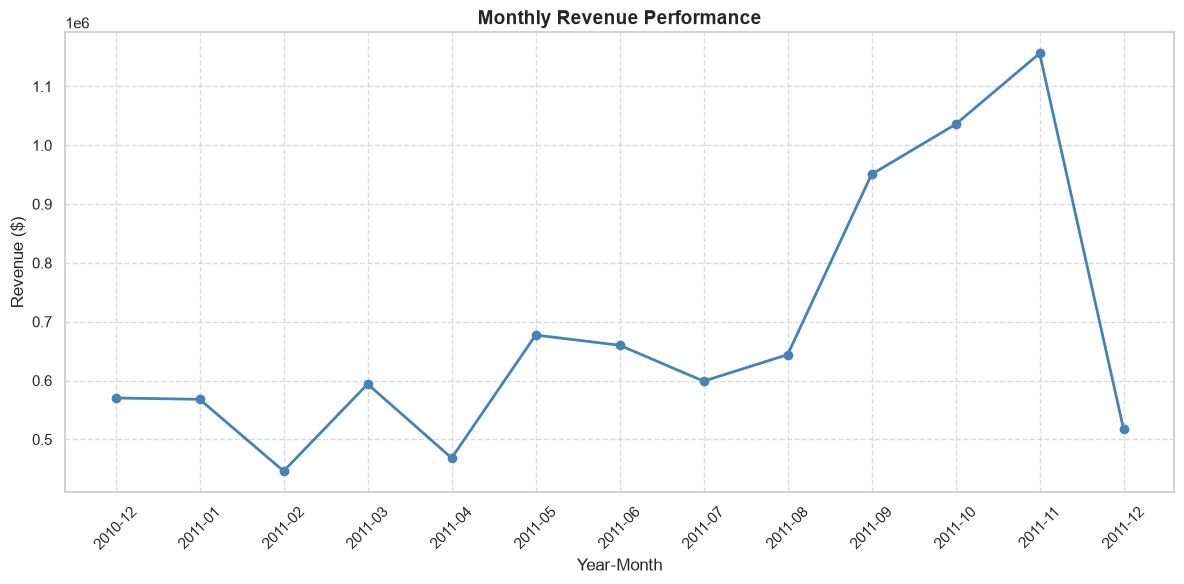


--- Key Sales Performance Insights ---
Strongest complete month: 2011-11 with $1,156,205.61 in revenue.
Weakest complete month: 2011-02 with $446,084.92 in revenue.
Total revenue from completed sales: $8,887,208.89
Total orders from completed sales: 18,532
Overall average order value: $479.56


In [6]:
# SALES PERFORMANCE AND REVENUE TREND ANALYSIS

# Keep completed sales only.
# Exclude cancelled invoices and returned or negative-quantity transactions.
sales_df = cleaned_df[
    ~cleaned_df['InvoiceNo'].astype(str).str.startswith('C')
    & (cleaned_df['Quantity'] > 0)
].copy()

# Calculate revenue for each transaction line
sales_df['TotalRevenue'] = (
    sales_df['Quantity'] * sales_df['UnitPrice']
)

# Create a monthly time period
sales_df['YearMonth'] = (
    sales_df['InvoiceDate'].dt.to_period('M')
)

# Aggregate monthly sales performance
monthly_sales = (
    sales_df.groupby('YearMonth')
    .agg(
        Total_Revenue=('TotalRevenue', 'sum'),
        Total_Orders=('InvoiceNo', 'nunique'),
        Total_Items=('Quantity', 'sum')
    )
    .reset_index()
)

# Calculate average order value
monthly_sales['AOV'] = (
    monthly_sales['Total_Revenue']
    / monthly_sales['Total_Orders']
)

# Display the complete monthly performance table
print('--- Monthly Sales Performance Summary ---')

display(
    monthly_sales.style.format({
        'Total_Revenue': '${:,.2f}',
        'AOV': '${:,.2f}',
        'Total_Orders': '{:,.0f}',
        'Total_Items': '{:,.0f}'
    })
)

# Plot monthly revenue trends
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['YearMonth'].astype(str),
    monthly_sales['Total_Revenue'],
    marker='o',
    color='steelblue',
    linewidth=2
)

plt.title(
    'Monthly Revenue Performance',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Identify the strongest and weakest complete months
# December 2011 is excluded because it is an incomplete month.
complete_monthly_sales = monthly_sales[
    monthly_sales['YearMonth'] != monthly_sales['YearMonth'].max()
].copy()

strongest_month = complete_monthly_sales.loc[
    complete_monthly_sales['Total_Revenue'].idxmax()
]

weakest_month = complete_monthly_sales.loc[
    complete_monthly_sales['Total_Revenue'].idxmin()
]

print('\n--- Key Sales Performance Insights ---')
print(
    f"Strongest complete month: {strongest_month['YearMonth']} "
    f"with ${strongest_month['Total_Revenue']:,.2f} in revenue."
)
print(
    f"Weakest complete month: {weakest_month['YearMonth']} "
    f"with ${weakest_month['Total_Revenue']:,.2f} in revenue."
)
print(
    f"Total revenue from completed sales: "
    f"${sales_df['TotalRevenue'].sum():,.2f}"
)
print(
    f"Total orders from completed sales: "
    f"{sales_df['InvoiceNo'].nunique():,}"
)
print(
    f"Overall average order value: "
    f"${sales_df.groupby('InvoiceNo')['TotalRevenue'].sum().mean():,.2f}"
)

# Sales Performance and Revenue Trend Analysis

## Executive Summary

After excluding cancelled invoices and returned or negative-quantity transactions, the business generated **$8.89M** in revenue from **18,532 orders**. The overall average order value was **$479.56**.

Sales strengthened considerably during the second half of 2011. November 2011 was the strongest complete month, generating **$1.16M** in revenue. February 2011 was the weakest complete month, generating **$446.1K**.

December 2011 should be interpreted carefully because the dataset ends on **9 December 2011**, making it an incomplete month.

## Monthly Performance Summary

| Month | Revenue | Orders | Items Sold | Average Order Value |
|---|---:|---:|---:|---:|
| Dec 2010 | $570,422.73 | 1,400 | 311,048 | $407.44 |
| Jan 2011 | $568,101.31 | 987 | 348,473 | $575.58 |
| Feb 2011 | $446,084.92 | 997 | 265,027 | $447.43 |
| Mar 2011 | $594,081.76 | 1,321 | 347,582 | $449.72 |
| Apr 2011 | $468,374.33 | 1,149 | 291,366 | $407.64 |
| May 2011 | $677,355.15 | 1,555 | 372,864 | $435.60 |
| Jun 2011 | $660,046.05 | 1,393 | 363,014 | $473.83 |
| Jul 2011 | $598,962.90 | 1,331 | 367,360 | $450.01 |
| Aug 2011 | $644,051.04 | 1,280 | 397,373 | $503.16 |
| Sep 2011 | $950,690.20 | 1,755 | 543,652 | $541.70 |
| Oct 2011 | $1,035,642.45 | 1,929 | 591,543 | $536.88 |
| Nov 2011 | $1,156,205.61 | 2,657 | 665,923 | $435.15 |
| Dec 2011* | $517,190.44 | 778 | 286,777 | $664.77 |

*December 2011 is incomplete.*

## Key Findings

- November 2011 was the strongest complete month.
- February 2011 was the weakest complete month.
- Revenue increased significantly from August through November.
- November's revenue growth was mainly driven by higher order volume.
- September and October recorded higher AOVs than November.

## Recommendations

1. Prepare inventory and fulfilment capacity before the September-November peak period.
2. Investigate the causes of the February low point.
3. Use bundles and cross-selling to improve AOV during high-volume months.
4. Exclude incomplete December data from full-month comparisons.
5. Combine monthly trends with product sales velocity for demand planning.

# GEOGRAPHIC SALES PERFORMANCE ANALYSIS

--- Geographic Performance Overview ---


,Market,Revenue,Revenue Share (%),Orders,Customers,Average Order Value
0,United Kingdom,"$7,285,024.64",82.0%,"16,646","3,920",$437.64
1,International Markets,"$1,602,184.25",18.0%,"1,886",426,$849.51



--- Top 5 International Markets by Revenue ---


,Country,Revenue,Orders,Customers,Average Order Value
Rank,,,,,
1,Netherlands,"$285,446.34",94,9,"$3,036.66"
2,EIRE,"$265,262.46",260,3,"$1,020.24"
3,Germany,"$228,678.40",457,94,$500.39
4,France,"$208,934.31",389,87,$537.11
5,Australia,"$138,453.81",57,9,"$2,429.01"


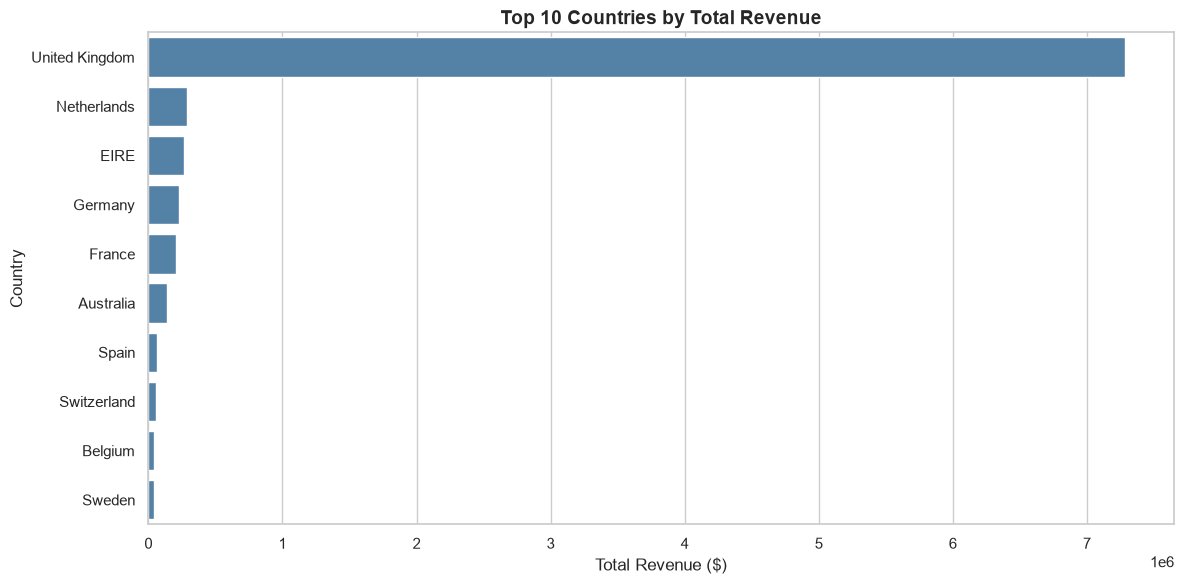


--- Key Geographic Insights ---
The business sold to 37 countries.
The five largest international markets contributed 70.3% of international revenue.
The UK generated 82.0% of revenue and 89.8% of orders.
The UK had 3,920 customers.


In [7]:
# Aggregate completed sales by country
geographic_sales = (
    sales_df.groupby('Country')
    .agg(
        Revenue=('TotalRevenue', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

# Calculate average order value by country
geographic_sales['AOV'] = (
    geographic_sales['Revenue']
    / geographic_sales['Orders']
)

# Rank countries by revenue
geographic_sales = (
    geographic_sales
    .sort_values('Revenue', ascending=False)
    .reset_index(drop=True)
)

# Separate the United Kingdom from international markets
uk_sales = geographic_sales[
    geographic_sales['Country'] == 'United Kingdom'
].iloc[0]

international_sales = geographic_sales[
    geographic_sales['Country'] != 'United Kingdom'
].copy()

total_revenue = geographic_sales['Revenue'].sum()
total_orders = geographic_sales['Orders'].sum()

# UK versus international market overview
market_overview = pd.DataFrame([
    {
        'Market': 'United Kingdom',
        'Revenue': uk_sales['Revenue'],
        'Revenue Share (%)': (
            uk_sales['Revenue'] / total_revenue * 100
        ),
        'Orders': uk_sales['Orders'],
        'Customers': uk_sales['Customers'],
        'Average Order Value': uk_sales['AOV']
    },
    {
        'Market': 'International Markets',
        'Revenue': international_sales['Revenue'].sum(),
        'Revenue Share (%)': (
            international_sales['Revenue'].sum()
            / total_revenue * 100
        ),
        'Orders': international_sales['Orders'].sum(),
        'Customers': international_sales['Customers'].sum(),
        'Average Order Value': (
            international_sales['Revenue'].sum()
            / international_sales['Orders'].sum()
        )
    }
])

print('--- Geographic Performance Overview ---')

display(
    market_overview.style.format({
        'Revenue': '${:,.2f}',
        'Revenue Share (%)': '{:.1f}%',
        'Orders': '{:,.0f}',
        'Customers': '{:,.0f}',
        'Average Order Value': '${:,.2f}'
    })
)

# Top five international markets by revenue
top_international_markets = (
    international_sales
    .head(5)
    [['Country', 'Revenue', 'Orders', 'Customers', 'AOV']]
    .copy()
    .reset_index(drop=True)
)

top_international_markets.index += 1
top_international_markets.index.name = 'Rank'

top_international_markets = (
    top_international_markets
    .rename(columns={'AOV': 'Average Order Value'})
)

print('\n--- Top 5 International Markets by Revenue ---')

display(
    top_international_markets.style.format({
        'Revenue': '${:,.2f}',
        'Orders': '{:,.0f}',
        'Customers': '{:,.0f}',
        'Average Order Value': '${:,.2f}'
    })
)

# Top 10 countries by revenue
top_countries = geographic_sales.head(10).copy()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_countries,
    x='Revenue',
    y='Country',
    color='steelblue'
)

plt.title(
    'Top 10 Countries by Total Revenue',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

# Supporting geographic metrics
total_countries = geographic_sales['Country'].nunique()

top_five_international_share = (
    top_international_markets['Revenue'].sum()
    / international_sales['Revenue'].sum()
    * 100
)

print('\n--- Key Geographic Insights ---')
print(f'The business sold to {total_countries} countries.')
print(
    f'The five largest international markets contributed '
    f'{top_five_international_share:.1f}% of international revenue.'
)
print(
    f"The UK generated "
    f"{uk_sales['Revenue'] / total_revenue * 100:.1f}% of revenue "
    f"and "
    f"{uk_sales['Orders'] / total_orders * 100:.1f}% of orders."
)
print(
    f"The UK had {uk_sales['Customers']:,} customers."
)

# Geographical Sales Performance Analysis

## Executive Summary

The United Kingdom remains the company's dominant market. It generated **$7.29M**, representing **82.0% of total revenue**, and accounted for **89.8% of orders**.

International markets generated **$1.60M**, or **18.0% of revenue**, from **1,886 orders**. Their average order value was **$849.51**, compared with **$437.64** in the United Kingdom.

The business sold to **37 countries**. The five largest international markets contributed **70.3% of international revenue**.

## Geographic Performance Overview

| Market | Revenue | Revenue Share | Orders | Customers | Average Order Value |
|---|---:|---:|---:|---:|---:|
| United Kingdom | $7,285,024.64 | 82.0% | 16,646 | 3,920 | $437.64 |
| International Markets | $1,602,184.25 | 18.0% | 1,886 | 426 | $849.51 |

## Top International Markets

| Rank | Country | Revenue | Orders | Customers | Average Order Value |
|---:|---|---:|---:|---:|---:|
| 1 | Netherlands | $285,446.34 | 94 | 9 | $3,036.66 |
| 2 | EIRE | $265,262.46 | 260 | 3 | $1,020.24 |
| 3 | Germany | $228,678.40 | 457 | 94 | $500.39 |
| 4 | France | $208,934.31 | 389 | 87 | $537.11 |
| 5 | Australia | $138,453.81 | 57 | 9 | $2,429.01 |

## Key Findings

### 1. The UK is the core market

The United Kingdom provides most of the company's revenue, orders, and customers. Protecting this customer base is essential.

### 2. International orders are higher value

International markets generate fewer orders than the UK but have a much higher average order value.

### 3. The Netherlands and Australia have concentrated sales

The Netherlands and Australia have high AOVs but only nine customers each. Their revenue may depend heavily on a small number of buyers.

### 4. Germany and France offer broader expansion potential

Germany and France have larger customer and order bases, making them more suitable for scalable marketing and repeat-purchase activity.

## Recommendations

1. Protect the UK market through customer retention and service improvements.
2. Maintain strong relationships with high-value customers in the Netherlands and Australia.
3. Develop marketing and repeat-purchase strategies for Germany and France.
4. Review international delivery costs, pricing, customs, and margins.
5. Monitor country concentration because some markets depend on very few customers.

Note: International customer totals are summed by country. A customer appearing in more than one country may be counted more than once.

# PRODUCT PERFORMANCE AND SALES VELOCITY ANALYSIS

--- Top 10 Products by Revenue ---


,StockCode,Description,Total_Quantity_Sold,Total_Revenue_Generated,Times_Ordered,Unique_Customers,First_Sale,Last_Sale,Units_Per_Day
2399,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995","$168,469.60",1,1,2011-12-09 09:15:00,2011-12-09 09:15:00,216.56
1288,22423,REGENCY CAKESTAND 3 TIER,"12,374","$142,264.75","1,703",881,2010-12-01 12:27:00,2011-12-09 10:20:00,33.09
3233,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"36,763","$100,547.45","1,978",856,2010-12-01 08:26:00,2011-12-09 11:34:00,98.30
3219,85099B,JUMBO BAG RED RETROSPOT,"46,078","$85,040.54","1,600",635,2010-12-01 09:57:00,2011-12-09 09:38:00,123.20
1997,23166,MEDIUM CERAMIC TOP STORAGE JAR,"77,916","$81,416.73",195,138,2011-01-18 10:01:00,2011-12-09 08:48:00,208.33
3664,POST,POSTAGE,"3,120","$77,803.96","1,099",331,2010-12-01 08:45:00,2011-12-09 12:16:00,8.34
2593,47566,PARTY BUNTING,"15,279","$68,785.23","1,379",708,2010-12-03 12:43:00,2011-12-08 15:31:00,40.85
3059,84879,ASSORTED COLOUR BIRD ORNAMENT,"35,263","$56,413.03","1,375",678,2010-12-01 08:34:00,2011-12-09 12:31:00,94.29
3662,M,Manual,"6,933","$53,419.93",253,197,2010-12-01 15:35:00,2011-12-08 13:50:00,18.54
1919,23084,RABBIT NIGHT LIGHT,"27,153","$51,251.24",801,450,2011-05-10 14:20:00,2011-12-09 12:31:00,72.60



--- Top 10 Products by Quantity Sold ---


,StockCode,Description,Total_Quantity_Sold,Total_Revenue_Generated,Times_Ordered,Unique_Customers,First_Sale,Last_Sale,Units_Per_Day
2399,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995","$168,469.60",1,1,2011-12-09 09:15:00,2011-12-09 09:15:00,216.56
1997,23166,MEDIUM CERAMIC TOP STORAGE JAR,"77,916","$81,416.73",195,138,2011-01-18 10:01:00,2011-12-09 08:48:00,208.33
2804,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"54,319","$13,558.41",472,307,2010-12-02 10:09:00,2011-12-09 08:59:00,145.24
1088,22197,SMALL POPCORN HOLDER,"49,160","$37,206.88","1,035",407,2010-12-01 10:19:00,2011-12-09 12:19:00,131.44
3219,85099B,JUMBO BAG RED RETROSPOT,"46,078","$85,040.54","1,600",635,2010-12-01 09:57:00,2011-12-09 09:38:00,123.20
3233,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"36,763","$100,547.45","1,978",856,2010-12-01 08:26:00,2011-12-09 11:34:00,98.30
3059,84879,ASSORTED COLOUR BIRD ORNAMENT,"35,263","$56,413.03","1,375",678,2010-12-01 08:34:00,2011-12-09 12:31:00,94.29
423,21212,PACK OF 72 RETROSPOT CAKE CASES,"33,670","$16,381.88","1,029",635,2010-12-01 09:37:00,2011-12-08 15:31:00,90.03
1919,23084,RABBIT NIGHT LIGHT,"27,153","$51,251.24",801,450,2011-05-10 14:20:00,2011-12-09 12:31:00,72.60
1352,22492,MINI PAINT SET VINTAGE,"26,076","$16,039.24",325,213,2010-12-01 08:45:00,2011-12-08 16:29:00,69.72



--- Top 10 Products by Sales Velocity ---


,StockCode,Description,Total_Quantity_Sold,Total_Revenue_Generated,Times_Ordered,Unique_Customers,First_Sale,Last_Sale,Units_Per_Day
2399,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995","$168,469.60",1,1,2011-12-09 09:15:00,2011-12-09 09:15:00,216.56
1997,23166,MEDIUM CERAMIC TOP STORAGE JAR,"77,916","$81,416.73",195,138,2011-01-18 10:01:00,2011-12-09 08:48:00,208.33
2804,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"54,319","$13,558.41",472,307,2010-12-02 10:09:00,2011-12-09 08:59:00,145.24
1088,22197,SMALL POPCORN HOLDER,"49,160","$37,206.88","1,035",407,2010-12-01 10:19:00,2011-12-09 12:19:00,131.44
3219,85099B,JUMBO BAG RED RETROSPOT,"46,078","$85,040.54","1,600",635,2010-12-01 09:57:00,2011-12-09 09:38:00,123.20
3233,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"36,763","$100,547.45","1,978",856,2010-12-01 08:26:00,2011-12-09 11:34:00,98.30
3059,84879,ASSORTED COLOUR BIRD ORNAMENT,"35,263","$56,413.03","1,375",678,2010-12-01 08:34:00,2011-12-09 12:31:00,94.29
423,21212,PACK OF 72 RETROSPOT CAKE CASES,"33,670","$16,381.88","1,029",635,2010-12-01 09:37:00,2011-12-08 15:31:00,90.03
1919,23084,RABBIT NIGHT LIGHT,"27,153","$51,251.24",801,450,2011-05-10 14:20:00,2011-12-09 12:31:00,72.60
1352,22492,MINI PAINT SET VINTAGE,"26,076","$16,039.24",325,213,2010-12-01 08:45:00,2011-12-08 16:29:00,69.72


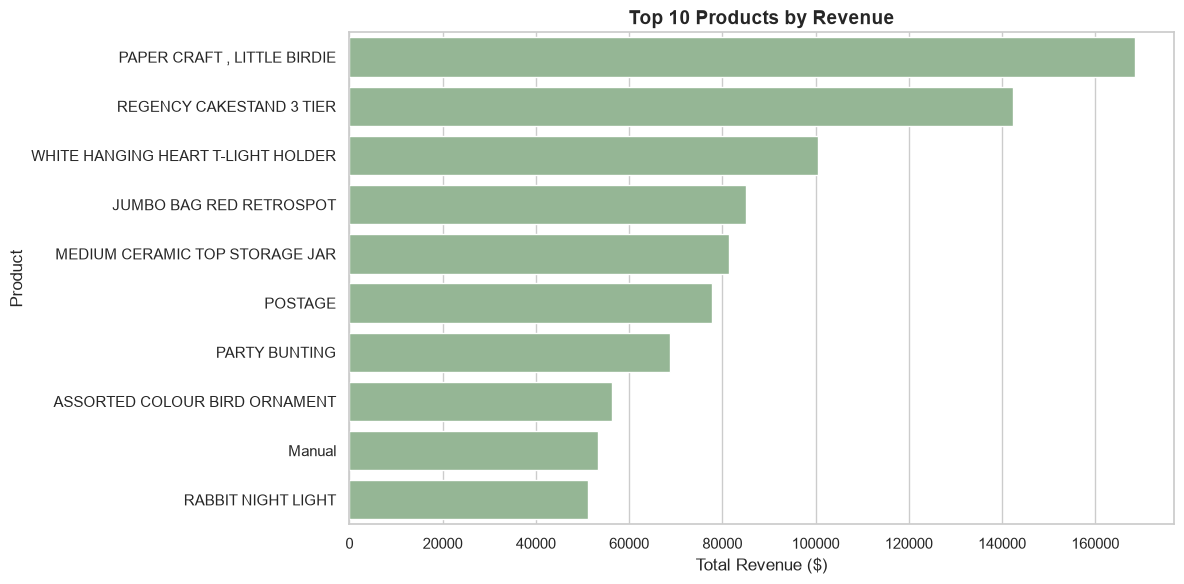


Note: This dataset does not contain stock-on-hand, reorder-point, supplier-lead-time, or replenishment fields. Therefore, Units_Per_Day is a sales-velocity proxy for inventory planning, not a direct measure of available inventory.


In [8]:
# Calculate product performance using completed sales only.
# Products are grouped by StockCode so description changes do not create duplicate product rows.
product_insights = (
    sales_df.groupby('StockCode')
    .agg(
        Description=('Description', 'first'),
        Total_Quantity_Sold=('Quantity', 'sum'),
        Total_Revenue_Generated=('TotalRevenue', 'sum'),
        Times_Ordered=('InvoiceNo', 'nunique'),
        Unique_Customers=('CustomerID', 'nunique'),
        First_Sale=('InvoiceDate', 'min'),
        Last_Sale=('InvoiceDate', 'max')
    )
    .reset_index()
)

# Calculate the number of days covered by the analysis
analysis_days = (
    sales_df['InvoiceDate'].max()
    - sales_df['InvoiceDate'].min()
).days + 1

# Estimate average units sold per day.
# This is a sales-velocity proxy, not actual stock-on-hand.
product_insights['Units_Per_Day'] = (
    product_insights['Total_Quantity_Sold']
    / analysis_days
)

# Rank products by revenue
top_10_by_revenue = (
    product_insights
    .sort_values(
        'Total_Revenue_Generated',
        ascending=False
    )
    .head(10)
)

print('--- Top 10 Products by Revenue ---')

display(
    top_10_by_revenue.style.format({
        'Total_Quantity_Sold': '{:,.0f}',
        'Total_Revenue_Generated': '${:,.2f}',
        'Times_Ordered': '{:,.0f}',
        'Unique_Customers': '{:,.0f}',
        'Units_Per_Day': '{:,.2f}'
    })
)

# Rank products by quantity sold
top_10_by_quantity = (
    product_insights
    .sort_values(
        'Total_Quantity_Sold',
        ascending=False
    )
    .head(10)
)

print('\n--- Top 10 Products by Quantity Sold ---')

display(
    top_10_by_quantity.style.format({
        'Total_Quantity_Sold': '{:,.0f}',
        'Total_Revenue_Generated': '${:,.2f}',
        'Times_Ordered': '{:,.0f}',
        'Unique_Customers': '{:,.0f}',
        'Units_Per_Day': '{:,.2f}'
    })
)

# Rank products by sales velocity
top_10_by_velocity = (
    product_insights
    .sort_values(
        'Units_Per_Day',
        ascending=False
    )
    .head(10)
)

print('\n--- Top 10 Products by Sales Velocity ---')

display(
    top_10_by_velocity.style.format({
        'Total_Quantity_Sold': '{:,.0f}',
        'Total_Revenue_Generated': '${:,.2f}',
        'Times_Ordered': '{:,.0f}',
        'Unique_Customers': '{:,.0f}',
        'Units_Per_Day': '{:,.2f}'
    })
)

# Plot the highest-revenue products
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_by_revenue,
    x='Total_Revenue_Generated',
    y='Description',
    color='darkseagreen'
)

plt.title(
    'Top 10 Products by Revenue',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.show()

print(
    '\nNote: This dataset does not contain stock-on-hand, '
    'reorder-point, supplier-lead-time, or replenishment fields. '
    'Therefore, Units_Per_Day is a sales-velocity proxy for inventory planning, '
    'not a direct measure of available inventory.'
)

# Product Performance and Sales Velocity Analysis

## Executive Summary

This analysis uses completed sales only, excluding cancelled invoices and returned or negative-quantity transactions.

Products are evaluated using three measures:

- **Revenue:** products generating the greatest financial contribution.
- **Quantity sold:** products with the highest unit demand.
- **Sales velocity:** average units sold per day across the analysis period.

The highest-revenue product was **PAPER CRAFT, LITTLE BIRDIE**, with **$168,469.60** in revenue.

## Top Products by Revenue

| Rank | Product | Quantity Sold | Revenue | Times Ordered | Customers | Units Per Day |
|---:|---|---:|---:|---:|---:|---:|
| 1 | PAPER CRAFT, LITTLE BIRDIE | 80,995 | $168,469.60 | 1 | 1 | 216.56 |
| 2 | REGENCY CAKESTAND 3 TIER | 12,374 | $142,264.75 | 1,703 | 881 | 33.09 |
| 3 | WHITE HANGING HEART T-LIGHT HOLDER | 36,763 | $100,547.45 | 1,978 | 856 | 98.30 |
| 4 | JUMBO BAG RED RETROSPOT | 46,078 | $85,040.54 | 1,600 | 635 | 123.20 |
| 5 | MEDIUM CERAMIC TOP STORAGE JAR | 77,916 | $81,416.73 | 195 | 138 | 208.33 |
| 6 | POSTAGE | 3,120 | $77,803.96 | 1,099 | 331 | 8.34 |
| 7 | PARTY BUNTING | 15,279 | $68,785.23 | 1,379 | 708 | 40.85 |
| 8 | ASSORTED COLOUR BIRD ORNAMENT | 35,263 | $56,413.03 | 1,375 | 678 | 94.29 |
| 9 | Manual | 6,933 | $53,419.93 | 253 | 197 | 18.54 |
| 10 | RABBIT NIGHT LIGHT | 27,153 | $51,251.24 | 801 | 450 | 72.60 |

## Key Findings

- PAPER CRAFT, LITTLE BIRDIE recorded the highest revenue, quantity sold, and sales velocity.
- MEDIUM CERAMIC TOP STORAGE JAR also recorded very high unit demand.
- REGENCY CAKESTAND 3 TIER had the broadest customer reach, with 881 customers.
- The quantity and sales-velocity rankings are similar because velocity is calculated using the same analysis period for every product.
- PAPER CRAFT, LITTLE BIRDIE generated 80,995 units from only one order on 9 December 2011. This appears to be a bulk or one-time transaction rather than sustained demand.
- POSTAGE and Manual appear in the revenue ranking but are operational entries rather than ordinary merchandise.

## Inventory Interpretation

Sales velocity is useful as an inventory-planning signal, but it is not actual inventory analysis. The dataset does not contain stock-on-hand, reorder points, supplier lead times, purchase orders, or replenishment records.

Therefore, this analysis cannot confirm whether a product is overstocked, understocked, or close to a stockout.

## Recommendations

1. Prioritise regularly ordered products for demand monitoring.
2. Investigate unusually large one-time transactions before setting recurring inventory targets.
3. Exclude POSTAGE, Manual, and other operational codes from merchandise planning.
4. Combine sales velocity with stock-on-hand and supplier lead-time data.
5. Track recent-period velocity separately from full-period velocity to distinguish sustained demand from isolated bulk orders.

# CANCELLATION AND RETURN ANALYSIS

--- Cancellation and Return Summary ---
Total financial value of cancellations and returns: $608,689.47
Total cancelled or returned transaction lines: 8,872
Total units cancelled or returned: 273,035
Cancelled invoices: 3,654
Cancellation rate by invoice: 16.47%

--- Top 10 Products by Cancelled or Returned Quantity ---


,StockCode,Description,Units_Cancelled_or_Returned,Revenue_Lost,Affected_Transactions
1516,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995","$168,469.60",1
1260,23166,MEDIUM CERAMIC TOP STORAGE JAR,"74,494","$77,479.64",10
1674,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"9,367",$298.65,3
1946,M,Manual,"3,995","$112,165.39",154
132,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,"3,150","$6,591.42",3
1839,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"2,578","$6,624.30",42
157,21175,GIN + TONIC DIET METAL SIGN,"2,030","$3,775.33",7
1069,22920,HERB MARKER BASIL,"1,527",$841.05,2
619,22273,FELTCRAFT DOLL MOLLY,"1,447","$3,512.65",5
1564,47566B,TEA TIME PARTY BUNTING,"1,424","$3,692.95",7



--- Monthly Cancellation and Return Trend ---


,YearMonth,Units_Cancelled_or_Returned,Revenue_Lost,Affected_Transactions
0,2010-12,"15,886","$18,049.87",308
1,2011-01,"79,767","$94,369.41",249
2,2011-02,"2,800","$10,550.85",204
3,2011-03,"4,528","$15,505.55",298
4,2011-04,"13,639","$43,151.66",235
5,2011-05,"5,833","$30,343.48",294
6,2011-06,"6,775","$53,183.53",314
7,2011-07,"6,013","$25,850.58",262
8,2011-08,"12,325","$28,972.95",263
9,2011-09,"7,304","$21,333.97",322


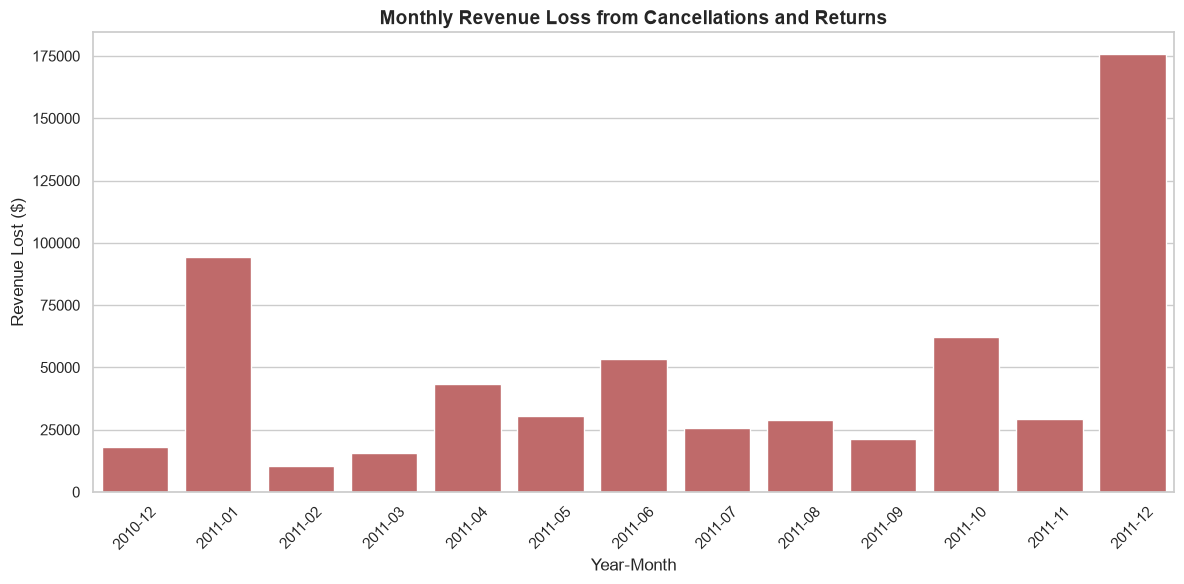

In [9]:
# Identify cancelled or returned transaction lines
cancellations = cleaned_df[
    cleaned_df['Quantity'] < 0
].copy()

# Calculate the financial value of each cancellation or return
cancellations['LossAmount'] = (
    cancellations['Quantity'].abs()
    * cancellations['UnitPrice']
)

# Identify cancellation invoices separately
cancellations['CancellationType'] = np.where(
    cancellations['InvoiceNo'].astype(str).str.startswith('C'),
    'Cancelled Invoice',
    'Returned Item'
)

# Overall cancellation and return metrics
total_revenue_loss = cancellations['LossAmount'].sum()
total_cancelled_lines = len(cancellations)
total_cancelled_units = cancellations['Quantity'].abs().sum()
cancelled_invoices = cancellations.loc[
    cancellations['CancellationType'] == 'Cancelled Invoice',
    'InvoiceNo'
].nunique()

total_invoices = cleaned_df['InvoiceNo'].nunique()

cancellation_rate = (
    cancelled_invoices / total_invoices * 100
)

print('--- Cancellation and Return Summary ---')
print(
    f'Total financial value of cancellations and returns: '
    f'${total_revenue_loss:,.2f}'
)
print(
    f'Total cancelled or returned transaction lines: '
    f'{total_cancelled_lines:,}'
)
print(
    f'Total units cancelled or returned: '
    f'{total_cancelled_units:,.0f}'
)
print(
    f'Cancelled invoices: {cancelled_invoices:,}'
)
print(
    f'Cancellation rate by invoice: {cancellation_rate:.2f}%'
)

# Top products by cancelled or returned quantity
top_cancelled_products = (
    cancellations
    .groupby(['StockCode', 'Description'])
    .agg(
        Units_Cancelled_or_Returned=('Quantity', lambda values: values.abs().sum()),
        Revenue_Lost=('LossAmount', 'sum'),
        Affected_Transactions=('InvoiceNo', 'nunique')
    )
    .reset_index()
    .sort_values(
        'Units_Cancelled_or_Returned',
        ascending=False
    )
    .head(10)
)

print('\n--- Top 10 Products by Cancelled or Returned Quantity ---')

display(
    top_cancelled_products.style.format({
        'Units_Cancelled_or_Returned': '{:,.0f}',
        'Revenue_Lost': '${:,.2f}',
        'Affected_Transactions': '{:,.0f}'
    })
)

# Monthly cancellation and return trend
cancellations['YearMonth'] = (
    cancellations['InvoiceDate'].dt.to_period('M')
)

monthly_cancellations = (
    cancellations.groupby('YearMonth')
    .agg(
        Units_Cancelled_or_Returned=('Quantity', lambda values: values.abs().sum()),
        Revenue_Lost=('LossAmount', 'sum'),
        Affected_Transactions=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

print('\n--- Monthly Cancellation and Return Trend ---')

display(
    monthly_cancellations.style.format({
        'Units_Cancelled_or_Returned': '{:,.0f}',
        'Revenue_Lost': '${:,.2f}',
        'Affected_Transactions': '{:,.0f}'
    })
)

# Plot monthly revenue loss
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_cancellations,
    x='YearMonth',
    y='Revenue_Lost',
    color='indianred'
)

plt.title(
    'Monthly Revenue Loss from Cancellations and Returns',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Year-Month')
plt.ylabel('Revenue Lost ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cancellation and Return Analysis

## Executive Summary

The analysis identified **8,872 negative-quantity transaction lines**, representing **273,035 cancelled or returned units**. The associated gross transaction value was **$608,689.47**.

There were **3,654 cancelled invoices**, producing an invoice-level cancellation rate of **16.47%** based on the cleaned transaction data.

These figures should be interpreted as the value associated with negative-quantity records. They represent gross transaction value rather than confirmed accounting loss or net profit loss.

## Key Findings

- January 2011 recorded **79,767 cancelled or returned units**, with a gross value of **$94,369.41**.
- December 2011 recorded the highest gross value of cancellations and returns at **$175,651.01**, although December is incomplete because the dataset ends on 9 December.
- The highest number of cancelled or returned units occurred in December, with **83,565 units**.
- **PAPER CRAFT, LITTLE BIRDIE** had **80,995 cancelled or returned units**, valued at **$168,469.60**, from only one affected transaction.
- **MEDIUM CERAMIC TOP STORAGE JAR** had **74,494 cancelled or returned units**, valued at **$77,479.64**, from ten affected transactions.
- The product-level results contain unusual cases where cancelled quantities exceed positive quantities sold. This may indicate bulk cancellations, adjustments, or transactions whose original sale occurred outside the analysed records.

## Business Interpretation

Cancellation activity is concentrated in a small number of products and months. The large quantities associated with PAPER CRAFT, LITTLE BIRDIE and MEDIUM CERAMIC TOP STORAGE JAR should be investigated individually before concluding that these products have ordinary customer-return problems.

The December result should not be compared directly with complete months. The analysis also cannot distinguish every operational reason for a negative quantity because the dataset does not contain a dedicated return-reason field.

## Recommendations

1. Investigate the largest product-level cancellations individually.
2. Separate genuine customer returns from order cancellations, stock adjustments, and data corrections.
3. Review January and December cancellation activity in more detail.
4. Compare cancellation activity with original invoice records where possible.
5. Use the gross loss values as monitoring indicators rather than confirmed profit losses.

# Recency-Frequency-Monetary_Value (RFM) CUSTOMER SEGMENTATION

--- Top 10 Customers by Monetary Value ---


,CustomerID,Recency,Frequency,Monetary,Last_Purchase,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
1689,14646,2,73,"$280,206.02",2011-12-08 12:12:00,5,5,5,555,Champions
4201,18102,1,60,"$259,657.30",2011-12-09 11:50:00,5,5,5,555,Champions
3728,17450,8,46,"$194,390.79",2011-12-01 13:29:00,5,5,5,555,Champions
3008,16446,1,2,"$168,472.50",2011-12-09 09:15:00,5,3,5,535,Loyal Customers
1879,14911,1,201,"$143,711.17",2011-12-08 15:54:00,5,5,5,555,Champions
55,12415,24,21,"$124,914.53",2011-11-15 14:22:00,4,5,5,455,Champions
1333,14156,10,55,"$117,210.08",2011-11-30 10:54:00,5,5,5,555,Champions
3771,17511,3,31,"$91,062.38",2011-12-07 10:12:00,5,5,5,555,Champions
2702,16029,39,63,"$80,850.84",2011-11-01 10:27:00,3,5,5,355,Potential Loyalists
0,12346,326,1,"$77,183.60",2011-01-18 10:01:00,1,1,5,115,Potential Loyalists



--- Customer Segment Summary ---


,Customer_Segment,Customers,Average_Recency,Average_Frequency,Total_Revenue,Average_Customer_Value
1,Champions,942,12.5,11.2,"$5,737,952.12","$6,091.24"
4,Potential Loyalists,1117,79.9,2.7,"$1,470,385.24","$1,316.37"
0,At Risk,661,150.6,3.4,"$823,912.44","$1,246.46"
3,Loyal Customers,483,15.7,3.0,"$524,228.04","$1,085.36"
2,Lost Customers,825,227.4,1.0,"$188,491.61",$228.47
5,Recent Customers,310,18.1,1.2,"$142,239.44",$458.84


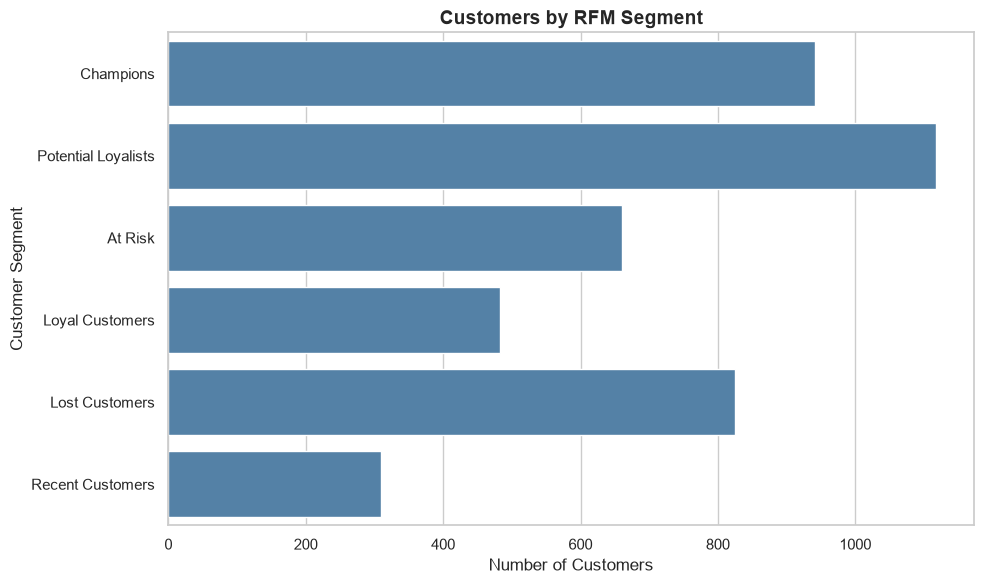

In [11]:
# Use completed positive-quantity sales only
rfm_sales = sales_df.copy()

# Set the reference date one day after the latest completed sale
snapshot_date = (
    rfm_sales['InvoiceDate'].max()
    + pd.Timedelta(days=1)
)

# Calculate customer-level RFM metrics
rfm = (
    rfm_sales.groupby('CustomerID')
    .agg(
        Recency=(
            'InvoiceDate',
            lambda dates: (snapshot_date - dates.max()).days
        ),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalRevenue', 'sum'),
        Last_Purchase=('InvoiceDate', 'max')
    )
    .reset_index()
)

# Use ranked values before qcut to avoid errors caused by duplicate values
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Combine the three scores
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

# Create practical customer segments
def assign_customer_segment(row):
    if (
        row['R_Score'] >= 4
        and row['F_Score'] >= 4
        and row['M_Score'] >= 4
    ):
        return 'Champions'
    elif (
        row['R_Score'] >= 4
        and row['F_Score'] >= 3
    ):
        return 'Loyal Customers'
    elif (
        row['R_Score'] >= 4
        and row['F_Score'] <= 2
    ):
        return 'Recent Customers'
    elif (
        row['R_Score'] <= 2
        and row['F_Score'] >= 3
    ):
        return 'At Risk'
    elif (
        row['R_Score'] <= 2
        and row['F_Score'] <= 2
        and row['M_Score'] <= 2
    ):
        return 'Lost Customers'
    else:
        return 'Potential Loyalists'

rfm['Customer_Segment'] = rfm.apply(
    assign_customer_segment,
    axis=1
)

# Display the highest-value customers
top_customers = (
    rfm
    .sort_values('Monetary', ascending=False)
    .head(10)
)

print('--- Top 10 Customers by Monetary Value ---')

display(
    top_customers.style.format({
        'Monetary': '${:,.2f}',
        'Recency': '{:,.0f}',
        'Frequency': '{:,.0f}'
    })
)

# Summarise each customer segment
segment_summary = (
    rfm.groupby('Customer_Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Average_Recency=('Recency', 'mean'),
        Average_Frequency=('Frequency', 'mean'),
        Total_Revenue=('Monetary', 'sum'),
        Average_Customer_Value=('Monetary', 'mean')
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
)

print('\n--- Customer Segment Summary ---')

display(
    segment_summary.style.format({
        'Average_Recency': '{:,.1f}',
        'Average_Frequency': '{:,.1f}',
        'Total_Revenue': '${:,.2f}',
        'Average_Customer_Value': '${:,.2f}'
    })
)

# Plot customer counts by segment
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x='Customers',
    y='Customer_Segment',
    color='steelblue'
)

plt.title(
    'Customers by RFM Segment',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

# Recency-Frequency-Monetary (RFM) Customer Segmentation

## Executive Summary

RFM analysis evaluates customers according to:

- **Recency:** how recently they purchased.
- **Frequency:** how often they purchased.
- **Monetary value:** how much revenue they generated.

The analysis uses completed positive-quantity sales only, so cancelled and returned transactions do not inflate customer value.

## Customer Segment Summary

| Segment | Customers | Average Recency | Average Frequency | Total Revenue | Average Customer Value |
|---|---:|---:|---:|---:|---:|
| Champions | 942 | 12.5 days | 11.2 orders | $5,737,952.12 | $6,091.24 |
| Potential Loyalists | 1,117 | 79.9 days | 2.7 orders | $1,470,385.24 | $1,316.37 |
| At Risk | 661 | 150.6 days | 3.4 orders | $823,912.44 | $1,246.46 |
| Loyal Customers | 483 | 15.7 days | 3.0 orders | $524,228.04 | $1,085.36 |
| Lost Customers | 825 | 227.4 days | 1.0 order | $188,491.61 | $228.47 |
| Recent Customers | 310 | 18.1 days | 1.2 orders | $142,239.44 | $458.84 |

## Key Findings

- The **Champions** segment contains 942 customers and generated **$5.74M**, the largest share of customer revenue.
- Champions purchased recently, averaging **12.5 days of recency**, and had the highest average frequency at **11.2 orders**.
- **Potential Loyalists** are the largest segment, with 1,117 customers. Their average frequency of 2.7 orders suggests an opportunity to encourage repeat purchasing.
- The **At Risk** segment contains 661 customers who previously purchased repeatedly but have not purchased recently.
- The **Lost Customers** segment contains 825 customers with an average recency of **227.4 days**, average frequency of one order, and average value of only **$228.47**.
- The top customer generated **$280,206.02** from 73 orders.

## Business Interpretation

The customer base includes a strong group of high-value, recently active customers. However, the At Risk and Lost segments show that some customer value may be recoverable through targeted reactivation campaigns.

The RFM scores are relative quintile scores. They rank customers against one another and do not represent fixed financial or behavioural thresholds.

## Recommendations

1. Protect Champions through loyalty benefits and personalised service.
2. Encourage Potential Loyalists to make additional purchases.
3. Use win-back campaigns for At Risk customers.
4. Avoid spending heavily on Lost Customers without testing their response.
5. Monitor the highest-value customers because a small number of customers contribute substantial revenue.

# REPEAT-PURCHASE ANALYSIS

--- Repeat-Purchase Summary ---
Total customers: 4,338
Repeat customers: 2,845
One-time customers: 1,493
Repeat-customer rate: 65.6%
Revenue generated by repeat customers: 93.1%

--- Customer Order-Frequency Distribution ---


,Total_Orders,Customers,Revenue
0,1,"1,493","$613,989.56"
1,2,835,"$737,463.75"
2,3,508,"$649,120.64"
3,4,388,"$554,165.63"
4,5,242,"$438,475.30"
5,6,172,"$413,690.92"
6,7,143,"$411,256.33"
7,8,98,"$295,088.61"
8,9,68,"$213,656.37"
9,10,54,"$176,335.77"



--- Top 10 Repeat Customers by Revenue ---


,CustomerID,Total_Orders,Total_Revenue,Total_Items,First_Order,Last_Order,Customer_Type
1689,14646,73,"$280,206.02","196,915",2010-12-20 10:09:00,2011-12-08 12:12:00,Repeat Customer
4201,18102,60,"$259,657.30","64,124",2010-12-07 16:42:00,2011-12-09 11:50:00,Repeat Customer
3728,17450,46,"$194,390.79","69,973",2010-12-07 09:23:00,2011-12-01 13:29:00,Repeat Customer
3008,16446,2,"$168,472.50","80,997",2011-05-18 09:52:00,2011-12-09 09:15:00,Repeat Customer
1879,14911,201,"$143,711.17","80,240",2010-12-01 14:05:00,2011-12-08 15:54:00,Repeat Customer
55,12415,21,"$124,914.53","77,374",2011-01-06 11:12:00,2011-11-15 14:22:00,Repeat Customer
1333,14156,55,"$117,210.08","57,768",2010-12-03 11:48:00,2011-11-30 10:54:00,Repeat Customer
3771,17511,31,"$91,062.38","64,549",2010-12-01 10:19:00,2011-12-07 10:12:00,Repeat Customer
2702,16029,63,"$80,850.84","40,108",2010-12-01 09:57:00,2011-11-01 10:27:00,Repeat Customer
3176,16684,28,"$66,653.56","50,255",2010-12-16 17:34:00,2011-12-05 14:06:00,Repeat Customer


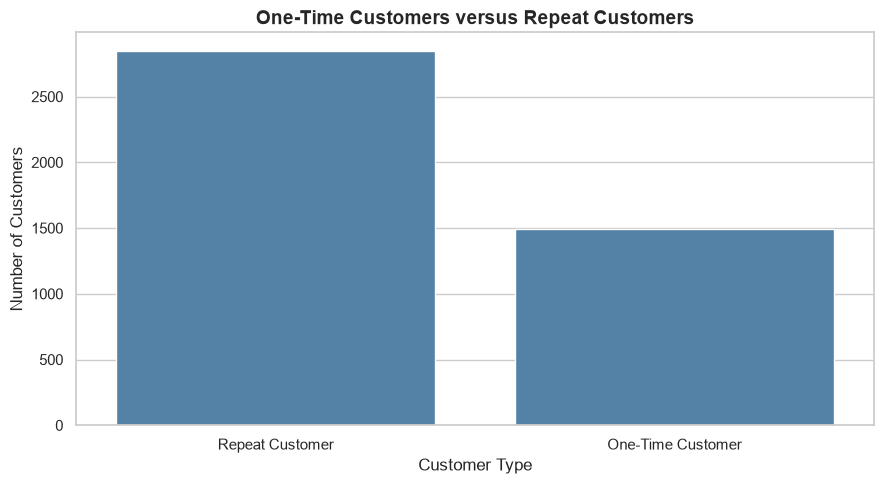

In [13]:
# Count completed orders per customer
customer_orders = (
    sales_df.groupby('CustomerID')
    .agg(
        Total_Orders=('InvoiceNo', 'nunique'),
        Total_Revenue=('TotalRevenue', 'sum'),
        Total_Items=('Quantity', 'sum'),
        First_Order=('InvoiceDate', 'min'),
        Last_Order=('InvoiceDate', 'max')
    )
    .reset_index()
)

# Classify customers by purchase behaviour
customer_orders['Customer_Type'] = np.where(
    customer_orders['Total_Orders'] == 1,
    'One-Time Customer',
    'Repeat Customer'
)

# Overall repeat-purchase metrics
total_customers = customer_orders['CustomerID'].nunique()
repeat_customers = (
    customer_orders['Customer_Type']
    .eq('Repeat Customer')
    .sum()
)
one_time_customers = total_customers - repeat_customers

repeat_customer_rate = (
    repeat_customers / total_customers * 100
)

repeat_customer_revenue = customer_orders.loc[
    customer_orders['Customer_Type'] == 'Repeat Customer',
    'Total_Revenue'
].sum()

total_customer_revenue = customer_orders['Total_Revenue'].sum()

repeat_revenue_share = (
    repeat_customer_revenue
    / total_customer_revenue
    * 100
)

print('--- Repeat-Purchase Summary ---')
print(f'Total customers: {total_customers:,}')
print(f'Repeat customers: {repeat_customers:,}')
print(f'One-time customers: {one_time_customers:,}')
print(f'Repeat-customer rate: {repeat_customer_rate:.1f}%')
print(f'Revenue generated by repeat customers: {repeat_revenue_share:.1f}%')

# Customer order-frequency distribution
order_frequency = (
    customer_orders
    .groupby('Total_Orders')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Revenue=('Total_Revenue', 'sum')
    )
    .reset_index()
    .sort_values('Total_Orders')
)

print('\n--- Customer Order-Frequency Distribution ---')

display(
    order_frequency.style.format({
        'Total_Orders': '{:,.0f}',
        'Customers': '{:,.0f}',
        'Revenue': '${:,.2f}'
    })
)

# Top repeat customers by revenue
top_repeat_customers = (
    customer_orders[
        customer_orders['Customer_Type'] == 'Repeat Customer'
    ]
    .sort_values('Total_Revenue', ascending=False)
    .head(10)
)

print('\n--- Top 10 Repeat Customers by Revenue ---')

display(
    top_repeat_customers.style.format({
        'Total_Orders': '{:,.0f}',
        'Total_Revenue': '${:,.2f}',
        'Total_Items': '{:,.0f}'
    })
)

# Plot one-time versus repeat customers
customer_type_summary = (
    customer_orders['Customer_Type']
    .value_counts()
    .rename_axis('Customer_Type')
    .reset_index(name='Customers')
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=customer_type_summary,
    x='Customer_Type',
    y='Customers',
    color='steelblue'
)

plt.title(
    'One-Time Customers versus Repeat Customers',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# Repeat-Purchase Analysis

## Executive Summary

The analysis identified **4,338 customers** who made completed purchases. Of these, **2,845 customers** were repeat customers and **1,493 customers** made only one purchase.

The repeat-customer rate was **65.6%**. Repeat customers generated **93.1% of total customer revenue**.

## Key Findings

- Repeat customers represented approximately two-thirds of the customer base.
- One-time customers generated **$613,989.56**.
- Customers with two orders generated **$737,463.75**.
- Customers with three orders generated **$649,120.64**.
- The highest-revenue repeat customer placed **73 orders** and generated **$280,206.02**.
- Other high-value repeat customers placed between 21 and 201 orders.

## Business Interpretation

Repeat customers are the main economic engine of the business. Although they represent 65.6% of customers, they generate 93.1% of customer revenue.

This indicates that customer retention is more important than relying only on new customer acquisition. The one-time customer group also represents a conversion opportunity, but the most valuable immediate opportunity is protecting and developing existing repeat customers.

The unusually high order volumes and revenue of some customers suggest that the business includes wholesale or bulk-buying behaviour.

## Recommendations

1. Prioritise retention campaigns for repeat customers.
2. Encourage one-time customers to place a second order.
3. Create separate strategies for ordinary retail customers and high-volume buyers.
4. Monitor customers with unusually large order counts for account-management opportunities.
5. Compare repeat-purchase rates by country, product category, and acquisition period.

# CUSTOMER COHORT ANALYSIS

--- Cohort Customer Retention (%) ---


Months Since First Purchase,1,2,3,4,5,6,7,8,9,10,11,12,13
Cohort_Month,,,,,,,,,,,,,
2010-12,100.0%,36.6%,32.3%,38.4%,36.3%,39.8%,36.3%,34.9%,35.4%,39.5%,37.4%,50.3%,26.6%
2011-01,100.0%,22.1%,26.6%,23.0%,32.1%,28.8%,24.7%,24.2%,30.0%,32.6%,36.5%,11.8%,nan%
2011-02,100.0%,18.7%,18.7%,28.4%,27.1%,24.7%,25.3%,27.9%,24.7%,30.5%,6.8%,nan%,nan%
2011-03,100.0%,15.0%,25.2%,19.9%,22.3%,16.8%,26.8%,23.0%,27.9%,8.6%,nan%,nan%,nan%
2011-04,100.0%,21.3%,20.3%,21.0%,19.7%,22.7%,21.7%,26.0%,7.3%,nan%,nan%,nan%,nan%
2011-05,100.0%,19.0%,17.3%,17.3%,20.8%,23.2%,26.4%,9.5%,nan%,nan%,nan%,nan%,nan%
2011-06,100.0%,17.4%,15.7%,26.4%,23.1%,33.5%,9.5%,nan%,nan%,nan%,nan%,nan%,nan%
2011-07,100.0%,18.1%,20.7%,22.3%,27.1%,11.2%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2011-08,100.0%,20.7%,24.9%,24.3%,12.4%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%



--- Cohort Revenue Table ---


Months Since First Purchase,1,2,3,4,5,6,7,8,9,10,11,12,13
Cohort_Month,,,,,,,,,,,,,
2010-12,"$570,422.73","$275,734.47","$233,390.47","$302,367.44","$204,034.38","$336,113.69","$313,668.16","$310,304.03","$331,001.07","$471,792.13","$455,478.90","$512,341.08","$185,360.97"
2011-01,"$292,366.84","$54,993.86","$63,157.01","$71,526.09","$80,989.77","$84,464.57","$70,073.35","$72,503.42","$71,870.48","$111,370.70","$123,252.86","$26,388.03",$nan
2011-02,"$157,700.59","$28,937.64","$40,964.47","$48,155.39","$40,089.17","$34,155.67","$49,673.71","$62,292.80","$55,241.34","$64,688.86","$10,600.22",$nan,$nan
2011-03,"$199,619.67","$30,040.34","$58,958.41","$42,739.08","$51,392.44","$39,962.33","$64,824.15","$70,523.62","$70,847.62","$12,761.10",$nan,$nan,$nan
2011-04,"$121,809.05","$29,398.59","$25,028.57","$24,282.79","$26,253.16","$30,103.24","$28,505.90","$34,009.61","$6,332.00",$nan,$nan,$nan,$nan
2011-05,"$123,739.30","$18,641.70","$20,155.73","$19,162.17","$27,752.62","$32,875.34","$33,168.34","$179,184.23",$nan,$nan,$nan,$nan,$nan
2011-06,"$135,414.80","$14,738.49","$14,104.37","$30,898.56","$26,669.90","$42,531.09","$8,143.22",$nan,$nan,$nan,$nan,$nan,$nan
2011-07,"$73,860.40","$11,789.67","$15,488.37","$17,391.93","$19,156.82","$6,040.70",$nan,$nan,$nan,$nan,$nan,$nan,$nan
2011-08,"$79,601.14","$20,933.76","$35,458.48","$44,487.65","$15,284.36",$nan,$nan,$nan,$nan,$nan,$nan,$nan,$nan


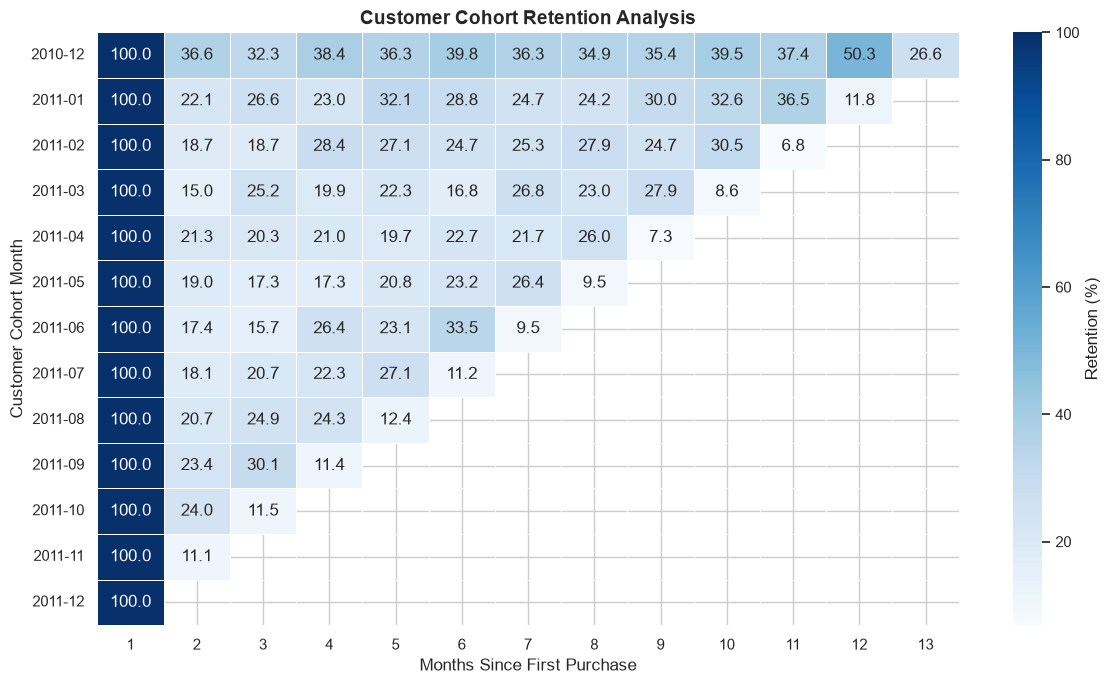


--- Cohort Retention Summary ---
Average first-month retention: 100.0%
Average retention after the first month: 25.1%


In [14]:
# Use completed sales only
cohort_sales = sales_df.copy()

# Convert transaction dates to monthly periods
cohort_sales['Order_Month'] = (
    cohort_sales['InvoiceDate'].dt.to_period('M')
)

# Find the month each customer first purchased
first_purchase = (
    cohort_sales.groupby('CustomerID')['Order_Month']
    .min()
    .rename('Cohort_Month')
)

# Attach each customer's cohort month to every transaction
cohort_sales = cohort_sales.merge(
    first_purchase,
    on='CustomerID',
    how='left'
)

# Calculate months since the customer's first purchase
cohort_sales['Cohort_Index'] = (
    (cohort_sales['Order_Month'].dt.year
     - cohort_sales['Cohort_Month'].dt.year) * 12
    + (cohort_sales['Order_Month'].dt.month
       - cohort_sales['Cohort_Month'].dt.month)
    + 1
)

# Count unique active customers by cohort and month
cohort_customer_counts = (
    cohort_sales
    .groupby(['Cohort_Month', 'Cohort_Index'])['CustomerID']
    .nunique()
    .reset_index(name='Active_Customers')
)

# Reshape into a cohort table
cohort_table = (
    cohort_customer_counts
    .pivot(
        index='Cohort_Month',
        columns='Cohort_Index',
        values='Active_Customers'
    )
    .sort_index()
)

# Calculate the original size of each cohort
cohort_sizes = cohort_table.iloc[:, 0]

# Calculate customer retention percentages
retention_table = (
    cohort_table
    .div(cohort_sizes, axis=0)
    * 100
)

retention_table.columns.name = 'Months Since First Purchase'

print('--- Cohort Customer Retention (%) ---')

display(
    retention_table.style.format('{:.1f}%')
)

# Calculate revenue by cohort and month
cohort_revenue = (
    cohort_sales
    .groupby(['Cohort_Month', 'Cohort_Index'])['TotalRevenue']
    .sum()
    .reset_index()
    .pivot(
        index='Cohort_Month',
        columns='Cohort_Index',
        values='TotalRevenue'
    )
    .sort_index()
)

cohort_revenue.columns.name = 'Months Since First Purchase'

print('\n--- Cohort Revenue Table ---')

display(
    cohort_revenue.style.format('${:,.2f}')
)

# Visualise customer retention
plt.figure(figsize=(12, 7))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Retention (%)'}
)

plt.title(
    'Customer Cohort Retention Analysis',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Customer Cohort Month')
plt.tight_layout()
plt.show()

# Summarise first-month and later-month retention
first_month_retention = retention_table[1].mean()

later_month_columns = [
    column for column in retention_table.columns
    if column >= 2
]

if later_month_columns:
    average_later_retention = (
        retention_table[later_month_columns]
        .mean()
        .mean()
    )
else:
    average_later_retention = np.nan

print('\n--- Cohort Retention Summary ---')
print(f'Average first-month retention: {first_month_retention:.1f}%')

if pd.notna(average_later_retention):
    print(
        f'Average retention after the first month: '
        f'{average_later_retention:.1f}%'
    )
else:
    print('There are not enough later months to calculate retention.')

# Customer Cohort Analysis

## Executive Summary

Customers were grouped into cohorts according to the month of their first completed purchase. Retention was then measured by tracking the percentage of each cohort that remained active in later months.

The analysis covers cohorts from **December 2010 to December 2011**.

## Retention Summary

The first month of every cohort is shown as **100% retention** because it represents the cohort's starting customer count.

Average retention after the first month was **25.1%**.

The December 2010 cohort was the largest and most mature cohort. Its retention ranged from:

- **36.6%** in month two
- **32.3%** in month three
- **50.3%** in month twelve
- **26.6%** in month thirteen

The January 2011 cohort recorded **22.1%** retention in month two and **36.5%** in month eleven. Later cohorts have fewer observable months because the dataset ends in December 2011.

## Key Findings

- Retention generally falls sharply after the first purchase month.
- The December 2010 cohort showed stronger long-term activity than many later cohorts.
- The December 2010 cohort generated substantial revenue throughout the observation period, including **$512,341.08** in month twelve.
- Recent cohorts cannot be compared fairly with older cohorts because they have had less time to make repeat purchases.
- Blank cells indicate months that had not yet occurred for that cohort, not necessarily zero retention.

## Business Interpretation

The results suggest that many customers do not purchase consistently after their first month. However, the presence of sustained activity in older cohorts shows that long-term retention is possible.

The apparent increases in some later months should be interpreted carefully because cohort activity is affected by seasonality, promotions, and the incomplete December 2011 observation period.

## Recommendations

1. Build retention campaigns during the first month after acquisition.
2. Compare cohorts using the same maturity window, such as month two or month six.
3. Investigate why the December 2010 cohort retained customers more effectively.
4. Use cohort results with RFM and repeat-purchase analysis for customer targeting.
5. Avoid treating the 100% first-month value as a retention achievement; it is the cohort baseline.

# PRODUCT RETURN-RATE ANALYSIS

--- Top 10 Products by Unit Return Rate (minimum 100 units sold) ---


,StockCode,Description,Units_Sold,Sales_Revenue,Sales_Orders,Returned_Units,Return_Revenue,Return_Transactions,Unit_Return_Rate,Revenue_Return_Rate
2844,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"7,892","$17,554.27",305,"9,367",$298.65,3,118.69%,1.70%
2403,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995","$168,469.60",1,"80,995","$168,469.60",1,100.00%,100.00%
2001,23166,MEDIUM CERAMIC TOP STORAGE JAR,"77,916","$81,416.73",195,"74,494","$77,479.64",10,95.61%,95.16%
3351,85232B,SET OF 3 BABUSHKA STACKING TINS,267,"$1,321.65",9,255,"$1,258.05",6,95.51%,95.19%
1948,23113,PANTRY CHOPPING BOARD,"1,138","$5,695.86",43,946,"$4,803.06",6,83.13%,84.33%
3162,85023B,EAU DE NILE JEWELLED PHOTOFRAME,104,$232.80,12,73,$153.75,2,70.19%,66.04%
2600,47566B,TEA TIME PARTY BUNTING,"2,288","$10,430.40",313,"1,424","$3,692.95",7,62.24%,35.41%
1897,23055,IVORY CHANDELIER T-LIGHT HOLDER,560,"$1,286.72",36,336,$594.72,4,60.00%,46.22%
3681,M,Manual,"6,933","$53,419.93",253,"3,995","$112,165.39",154,57.62%,209.97%
1898,23056,FLOWERS CHANDELIER T-LIGHT HOLDER,866,"$2,789.66",37,483,"$1,763.07",6,55.77%,63.20%



--- Top 10 Products by Returned Units ---


,StockCode,Description,Units_Sold,Sales_Revenue,Sales_Orders,Returned_Units,Return_Revenue,Return_Transactions,Unit_Return_Rate,Revenue_Return_Rate
2403,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995","$168,469.60",1,"80,995","$168,469.60",1,100.00%,100.00%
2001,23166,MEDIUM CERAMIC TOP STORAGE JAR,"77,916","$81,416.73",195,"74,494","$77,479.64",10,95.61%,95.16%
2844,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"7,892","$17,554.27",305,"9,367",$298.65,3,118.69%,1.70%
3681,M,Manual,"6,933","$53,419.93",253,"3,995","$112,165.39",154,57.62%,209.97%
356,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,"10,070","$17,291.57",192,"3,150","$6,591.42",3,31.28%,38.12%
3249,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"36,763","$100,547.45","1,978","2,578","$6,624.30",42,7.01%,6.59%
399,21175,GIN + TONIC DIET METAL SIGN,"11,975","$26,063.34",692,"2,030","$3,775.33",7,16.95%,14.49%
1766,22920,HERB MARKER BASIL,"3,325","$1,997.75",188,"1,527",$841.05,2,45.92%,42.10%
1156,22273,FELTCRAFT DOLL MOLLY,"4,464","$11,748.24",293,"1,447","$3,512.65",5,32.41%,29.90%
2600,47566B,TEA TIME PARTY BUNTING,"2,288","$10,430.40",313,"1,424","$3,692.95",7,62.24%,35.41%



--- Overall Product Return Summary ---
Total units sold: 5,152,002
Total units returned: 273,035
Overall unit return rate: 5.30%
Total sales revenue: $8,887,208.89
Total returned revenue: $608,689.47
Overall revenue return rate: 6.85%


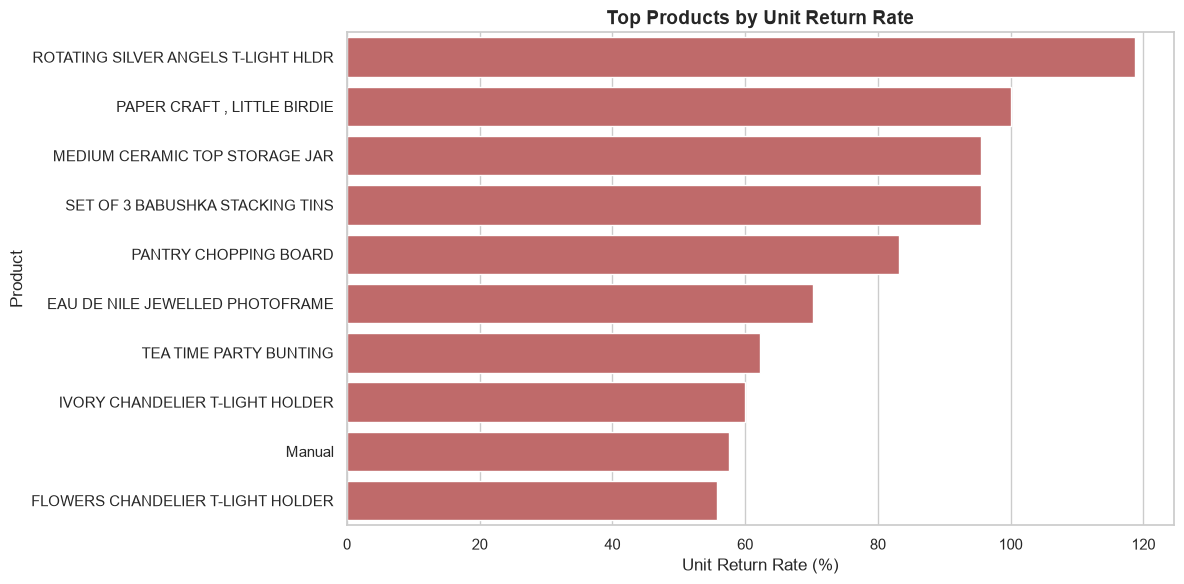

In [15]:
# Positive quantities represent completed sales
product_sales = (
    sales_df.groupby('StockCode')
    .agg(
        Description=('Description', 'first'),
        Units_Sold=('Quantity', 'sum'),
        Sales_Revenue=('TotalRevenue', 'sum'),
        Sales_Orders=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

# Negative quantities represent cancellations or returns
product_returns = (
    cancellations.groupby('StockCode')
    .agg(
        Returned_Units=('Quantity', lambda values: values.abs().sum()),
        Return_Revenue=('LossAmount', 'sum'),
        Return_Transactions=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

# Combine sales and return information
product_return_analysis = product_sales.merge(
    product_returns,
    on='StockCode',
    how='outer'
)

# Fill products with no returns
numeric_columns = [
    'Units_Sold',
    'Sales_Revenue',
    'Sales_Orders',
    'Returned_Units',
    'Return_Revenue',
    'Return_Transactions'
]

for column in numeric_columns:
    product_return_analysis[column] = (
        product_return_analysis[column].fillna(0)
    )

# Restore product descriptions for products appearing only in returns
product_return_analysis['Description'] = (
    product_return_analysis['Description']
    .fillna('Unknown Product')
)

# Calculate unit and revenue return rates
product_return_analysis['Unit_Return_Rate'] = np.where(
    product_return_analysis['Units_Sold'] > 0,
    product_return_analysis['Returned_Units']
    / product_return_analysis['Units_Sold']
    * 100,
    np.nan
)

product_return_analysis['Revenue_Return_Rate'] = np.where(
    product_return_analysis['Sales_Revenue'] > 0,
    product_return_analysis['Return_Revenue']
    / product_return_analysis['Sales_Revenue']
    * 100,
    np.nan
)

# Require a minimum sales volume to avoid misleading rates
minimum_units_sold = 100

qualified_return_analysis = product_return_analysis[
    product_return_analysis['Units_Sold'] >= minimum_units_sold
].copy()

# Rank products by unit return rate
top_return_rate_products = (
    qualified_return_analysis
    .sort_values('Unit_Return_Rate', ascending=False)
    .head(10)
)

print(
    f'--- Top 10 Products by Unit Return Rate '
    f'(minimum {minimum_units_sold} units sold) ---'
)

display(
    top_return_rate_products.style.format({
        'Units_Sold': '{:,.0f}',
        'Returned_Units': '{:,.0f}',
        'Sales_Revenue': '${:,.2f}',
        'Return_Revenue': '${:,.2f}',
        'Sales_Orders': '{:,.0f}',
        'Return_Transactions': '{:,.0f}',
        'Unit_Return_Rate': '{:.2f}%',
        'Revenue_Return_Rate': '{:.2f}%'
    })
)

# Rank products by total returned units
top_returned_products = (
    product_return_analysis
    .sort_values('Returned_Units', ascending=False)
    .head(10)
)

print('\n--- Top 10 Products by Returned Units ---')

display(
    top_returned_products.style.format({
        'Units_Sold': '{:,.0f}',
        'Returned_Units': '{:,.0f}',
        'Sales_Revenue': '${:,.2f}',
        'Return_Revenue': '${:,.2f}',
        'Sales_Orders': '{:,.0f}',
        'Return_Transactions': '{:,.0f}',
        'Unit_Return_Rate': '{:.2f}%',
        'Revenue_Return_Rate': '{:.2f}%'
    })
)

# Overall return-rate metrics
total_units_sold = product_return_analysis['Units_Sold'].sum()
total_units_returned = product_return_analysis['Returned_Units'].sum()
total_sales_revenue = product_return_analysis['Sales_Revenue'].sum()
total_return_revenue = product_return_analysis['Return_Revenue'].sum()

overall_unit_return_rate = (
    total_units_returned
    / total_units_sold
    * 100
)

overall_revenue_return_rate = (
    total_return_revenue
    / total_sales_revenue
    * 100
)

print('\n--- Overall Product Return Summary ---')
print(f'Total units sold: {total_units_sold:,.0f}')
print(f'Total units returned: {total_units_returned:,.0f}')
print(f'Overall unit return rate: {overall_unit_return_rate:.2f}%')
print(f'Total sales revenue: ${total_sales_revenue:,.2f}')
print(f'Total returned revenue: ${total_return_revenue:,.2f}')
print(
    f'Overall revenue return rate: '
    f'{overall_revenue_return_rate:.2f}%'
)

# Plot products with the highest qualified return rates
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_return_rate_products,
    x='Unit_Return_Rate',
    y='Description',
    color='indianred'
)

plt.title(
    'Top Products by Unit Return Rate',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Unit Return Rate (%)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# Product Return-Rate Analysis

## Executive Summary

The product return analysis compares positive-quantity sales with negative-quantity cancellations or returns.

Across the dataset:

- **5,152,002 units** were sold.
- **273,035 units** were cancelled or returned.
- The overall unit return rate was **5.30%**.
- Completed sales revenue was **$8.89M**.
- The gross value associated with returned units was **$608,689.47**.
- The overall revenue return rate was **6.85%**.

## Key Findings

The highest qualified unit return rates were:

| Product | Units Sold | Returned Units | Unit Return Rate |
|---|---:|---:|---:|
| ROTATING SILVER ANGELS T-LIGHT HLDR | 7,892 | 9,367 | 118.69% |
| PAPER CRAFT, LITTLE BIRDIE | 80,995 | 80,995 | 100.00% |
| MEDIUM CERAMIC TOP STORAGE JAR | 77,916 | 74,494 | 95.61% |
| SET OF 3 BABUSHKA STACKING TINS | 267 | 255 | 95.51% |
| PANTRY CHOPPING BOARD | 1,138 | 946 | 83.13% |

The analysis applies a minimum threshold of 100 units sold to reduce the effect of very small sales volumes.

## Important Interpretation

Some return rates exceed 100%. This means the negative-quantity records contain more units than the positive-quantity records attributed to the same product in this dataset.

This may be caused by bulk cancellations, corrections, returns linked to earlier transactions, or incomplete matching between original sales and negative transactions. It should not automatically be interpreted as a literal customer return rate.

The `Manual` entry is an operational code rather than a standard product and should not be used for normal merchandise-quality decisions.

## Recommendations

1. Investigate products with return rates above 100% at invoice level.
2. Separate true customer returns from cancellations and accounting adjustments.
3. Exclude Manual and other operational codes from merchandise return analysis.
4. Use both return rate and returned-unit volume when prioritising investigations.
5. Match returns to original sales invoices if a more precise return rate is required.

# BASKET-SIZE ANALYSIS

--- Basket Summary ---
Average items per order: 278.01
Average products per order: 20.93
Average order revenue: $479.56

--- Basket-Size Summary ---


,Basket_Category,Orders,Average_Items,Average_Revenue,Total_Revenue
0,1-5 items,513,2.37,$145.89,"$74,839.46"
1,6-10 items,258,7.85,$44.44,"$11,464.86"
2,11-20 items,568,15.19,$62.78,"$35,658.30"
3,21-50 items,"1,784",36.05,$123.04,"$219,497.06"
4,More than 50 items,"15,409",329.41,$554.59,"$8,545,749.21"


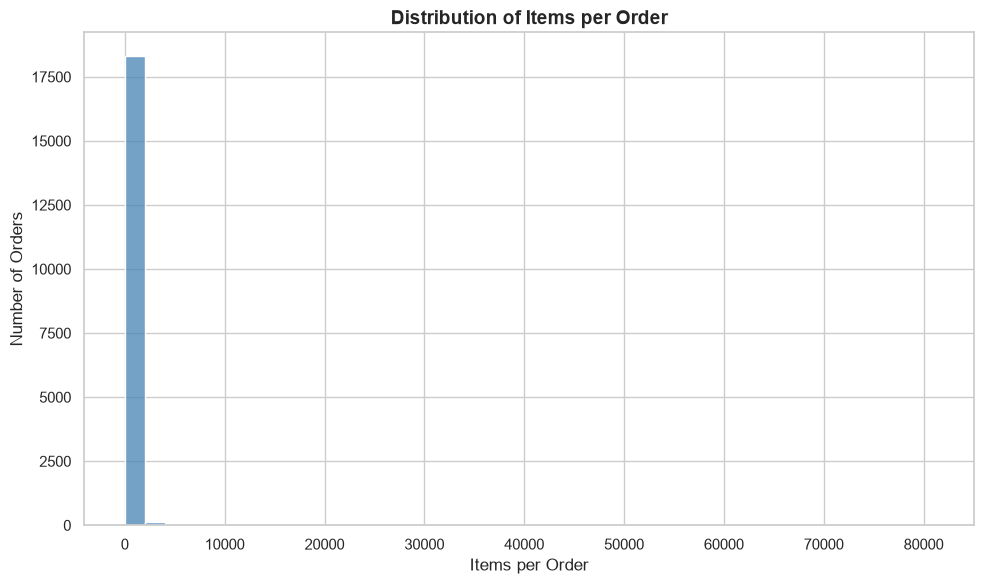

In [16]:
# Summarise each completed order
order_baskets = (
    sales_df.groupby('InvoiceNo')
    .agg(
        CustomerID=('CustomerID', 'first'),
        Order_Date=('InvoiceDate', 'min'),
        Unique_Products=('StockCode', 'nunique'),
        Total_Items=('Quantity', 'sum'),
        Order_Revenue=('TotalRevenue', 'sum')
    )
    .reset_index()
)

# Create basket-size categories
order_baskets['Basket_Category'] = pd.cut(
    order_baskets['Total_Items'],
    bins=[0, 5, 10, 20, 50, float('inf')],
    labels=[
        '1-5 items',
        '6-10 items',
        '11-20 items',
        '21-50 items',
        'More than 50 items'
    ]
)

print('--- Basket Summary ---')
print(
    f"Average items per order: "
    f"{order_baskets['Total_Items'].mean():.2f}"
)
print(
    f"Average products per order: "
    f"{order_baskets['Unique_Products'].mean():.2f}"
)
print(
    f"Average order revenue: "
    f"${order_baskets['Order_Revenue'].mean():,.2f}"
)

basket_summary = (
    order_baskets
    .groupby('Basket_Category', observed=False)
    .agg(
        Orders=('InvoiceNo', 'nunique'),
        Average_Items=('Total_Items', 'mean'),
        Average_Revenue=('Order_Revenue', 'mean'),
        Total_Revenue=('Order_Revenue', 'sum')
    )
    .reset_index()
)

print('\n--- Basket-Size Summary ---')

display(
    basket_summary.style.format({
        'Orders': '{:,.0f}',
        'Average_Items': '{:,.2f}',
        'Average_Revenue': '${:,.2f}',
        'Total_Revenue': '${:,.2f}'
    })
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=order_baskets,
    x='Total_Items',
    bins=40,
    color='steelblue'
)

plt.title(
    'Distribution of Items per Order',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Items per Order')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# Basket-Size Analysis

## Executive Summary

The basket analysis examined completed orders using total items, unique products, and order revenue.

The average order contained:

- **278.01 items**
- **20.93 unique products**
- **$479.56 in revenue**

The results are strongly affected by bulk orders.

## Basket-Size Summary

| Basket Category | Orders | Average Items | Average Revenue | Total Revenue |
|---|---:|---:|---:|---:|
| 1-5 items | 513 | 2.37 | $145.89 | $74,839.46 |
| 6-10 items | 258 | 7.85 | $44.44 | $11,464.86 |
| 11-20 items | 568 | 15.19 | $62.78 | $35,658.30 |
| 21-50 items | 1,784 | 36.05 | $123.04 | $219,497.06 |
| More than 50 items | 15,409 | 329.41 | $554.59 | $8,545,749.21 |

## Key Findings

- Orders containing more than 50 items represented the overwhelming majority of orders and revenue.
- The largest basket category generated approximately **$8.55M**.
- The average basket size is heavily influenced by a small number of extremely large orders.
- The histogram shows a strongly right-skewed distribution, with most orders concentrated at lower item counts and a long tail of bulk transactions.
- The 6-10 item category has lower average revenue than the 1-5 item category, showing that item count alone does not determine order value.

## Business Interpretation

The transaction data appears to combine ordinary retail orders with wholesale or bulk purchasing. Therefore, the overall average of 278 items per order is not representative of a typical customer basket.

Median basket size and separate retail-versus-bulk analysis would provide a more typical view of customer behaviour.

## Recommendations

1. Report median items per order alongside the mean.
2. Separate bulk orders from ordinary retail orders.
3. Analyse AOV and basket size separately for each customer type.
4. Use basket-size patterns to support packaging and fulfilment planning.
5. Investigate large orders before using the overall average for operational planning.

# DAY-OF-WEEK AND HOURLY SALES ANALYSIS

--- Sales by Day of Week ---


,Day_of_Week,Revenue,Orders,Items_Sold,AOV
0,Monday,"$1,363,604.40","2,863","766,911",$476.29
1,Tuesday,"$1,697,733.80","3,184","1,005,760",$533.21
2,Wednesday,"$1,584,283.83","3,455","960,082",$458.55
3,Thursday,"$1,973,015.73","4,032","1,149,619",$489.34
4,Friday,"$1,483,080.81","2,829","808,648",$524.24
5,Saturday,$0.00,0,0,$nan
6,Sunday,"$785,490.32","2,169","460,982",$362.14



--- Sales by Hour ---


,Hour,Revenue,Orders,Items_Sold,AOV
0,6,$4.25,1,1,$4.25
1,7,"$31,059.21",29,"15,370","$1,071.01"
2,8,"$281,997.79",555,"157,815",$508.10
3,9,"$842,392.34","1,393","482,216",$604.73
4,10,"$1,259,267.59","2,226","774,799",$565.71
5,11,"$1,101,177.60","2,277","645,056",$483.61
6,12,"$1,373,695.39","3,130","822,368",$438.88
7,13,"$1,168,724.20","2,636","680,275",$443.37
8,14,"$991,992.82","2,274","555,896",$436.23
9,15,"$963,559.68","2,037","539,004",$473.03


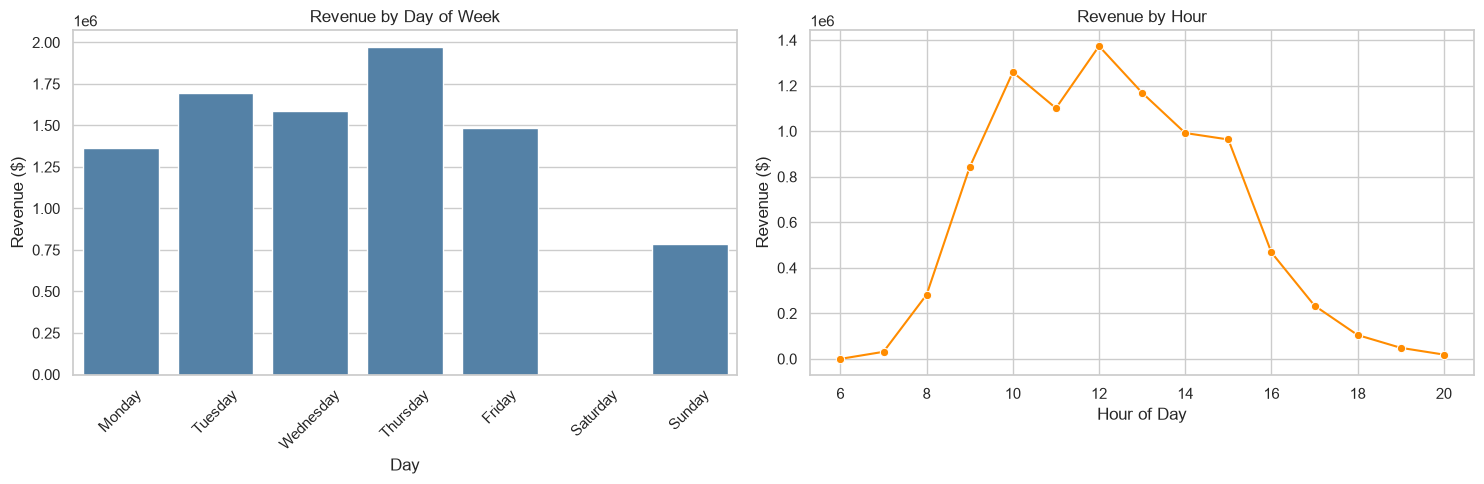

In [17]:
timing_sales = sales_df.copy()

timing_sales['Day_of_Week'] = (
    timing_sales['InvoiceDate'].dt.day_name()
)

timing_sales['Hour'] = (
    timing_sales['InvoiceDate'].dt.hour
)

# Ensure the days appear in calendar order
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

timing_sales['Day_of_Week'] = pd.Categorical(
    timing_sales['Day_of_Week'],
    categories=day_order,
    ordered=True
)

day_summary = (
    timing_sales.groupby('Day_of_Week', observed=False)
    .agg(
        Revenue=('TotalRevenue', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Items_Sold=('Quantity', 'sum')
    )
    .reset_index()
)

day_summary['AOV'] = (
    day_summary['Revenue'] / day_summary['Orders']
)

print('--- Sales by Day of Week ---')

display(
    day_summary.style.format({
        'Revenue': '${:,.2f}',
        'Orders': '{:,.0f}',
        'Items_Sold': '{:,.0f}',
        'AOV': '${:,.2f}'
    })
)

hour_summary = (
    timing_sales.groupby('Hour')
    .agg(
        Revenue=('TotalRevenue', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Items_Sold=('Quantity', 'sum')
    )
    .reset_index()
)

hour_summary['AOV'] = (
    hour_summary['Revenue'] / hour_summary['Orders']
)

print('\n--- Sales by Hour ---')

display(
    hour_summary.style.format({
        'Hour': '{:,.0f}',
        'Revenue': '${:,.2f}',
        'Orders': '{:,.0f}',
        'Items_Sold': '{:,.0f}',
        'AOV': '${:,.2f}'
    })
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=day_summary,
    x='Day_of_Week',
    y='Revenue',
    color='steelblue',
    ax=axes[0]
)

axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(
    data=hour_summary,
    x='Hour',
    y='Revenue',
    marker='o',
    color='darkorange',
    ax=axes[1]
)

axes[1].set_title('Revenue by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

# Day-of-Week and Hourly Sales Analysis

## Executive Summary

Sales activity varies substantially by day and hour. The strongest day by revenue was **Thursday**, while the weakest active day was **Sunday**. No Saturday transactions were recorded in the dataset.

## Sales by Day

| Day | Revenue | Orders | Items Sold | AOV |
|---|---:|---:|---:|---:|
| Monday | $1,363,604.40 | 2,863 | 766,911 | $476.29 |
| Tuesday | $1,697,733.80 | 3,184 | 1,005,760 | $533.21 |
| Wednesday | $1,584,283.83 | 3,455 | 960,082 | $458.55 |
| Thursday | $1,973,015.73 | 4,032 | 1,149,619 | $489.34 |
| Friday | $1,483,080.81 | 2,829 | 808,648 | $524.24 |
| Saturday | $0.00 | 0 | 0 | Not applicable |
| Sunday | $785,490.32 | 2,169 | 460,982 | $362.14 |

## Sales by Hour

Revenue was concentrated between **9:00 and 16:00**.

The strongest hour was **12:00**, generating **$1,373,695.39** from 3,130 orders. Other strong periods were:

- 10:00: **$1,259,267.59**
- 13:00: **$1,168,724.20**
- 11:00: **$1,101,177.60**
- 14:00: **$991,992.82**

Sales before 8:00 and after 18:00 were comparatively limited.

## Key Findings

- Thursday generated the highest revenue and the highest number of orders.
- Tuesday had the highest AOV at **$533.21** among the regular high-volume days.
- Sunday had the lowest active-day AOV at **$362.14**.
- Saturday had no recorded transactions, which may reflect business operating hours rather than customer demand.
- The busiest selling window was broadly late morning to early afternoon.

## Recommendations

1. Schedule fulfilment and customer-service resources around Thursday and the 9:00-16:00 period.
2. Investigate the absence of Saturday transactions.
3. Compare operating hours with the observed transaction pattern.
4. Use Tuesday and Friday customer behaviour to study high-AOV opportunities.
5. Do not interpret hour-level results as website traffic patterns because the dataset records transaction times, not browsing activity.

# PARETO ANALYSIS OF PRODUCTS AND CUSTOMERS

--- Product Pareto Analysis ---
776 products generate approximately 80% of product revenue.


,StockCode,Description,Revenue,Cumulative_Revenue,Cumulative_Revenue_Percent
2399,23843,"PAPER CRAFT , LITTLE BIRDIE","$168,469.60","$168,469.60",1.9%
1288,22423,REGENCY CAKESTAND 3 TIER,"$142,264.75","$310,734.35",3.5%
3233,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"$100,547.45","$411,281.80",4.6%
3219,85099B,JUMBO BAG RED RETROSPOT,"$85,040.54","$496,322.34",5.6%
1997,23166,MEDIUM CERAMIC TOP STORAGE JAR,"$81,416.73","$577,739.07",6.5%
3664,POST,POSTAGE,"$77,803.96","$655,543.03",7.4%
2593,47566,PARTY BUNTING,"$68,785.23","$724,328.26",8.2%
3059,84879,ASSORTED COLOUR BIRD ORNAMENT,"$56,413.03","$780,741.29",8.8%
3662,M,Manual,"$53,419.93","$834,161.22",9.4%
1919,23084,RABBIT NIGHT LIGHT,"$51,251.24","$885,412.46",10.0%



--- Customer Pareto Analysis ---
1,130 customers generate approximately 80% of customer revenue.


,CustomerID,Revenue,Cumulative_Revenue,Cumulative_Revenue_Percent
1689,14646,"$280,206.02","$280,206.02",3.2%
4201,18102,"$259,657.30","$539,863.32",6.1%
3728,17450,"$194,390.79","$734,254.11",8.3%
3008,16446,"$168,472.50","$902,726.61",10.2%
1879,14911,"$143,711.17","$1,046,437.78",11.8%
55,12415,"$124,914.53","$1,171,352.31",13.2%
1333,14156,"$117,210.08","$1,288,562.39",14.5%
3771,17511,"$91,062.38","$1,379,624.77",15.5%
2702,16029,"$80,850.84","$1,460,475.61",16.4%
0,12346,"$77,183.60","$1,537,659.21",17.3%


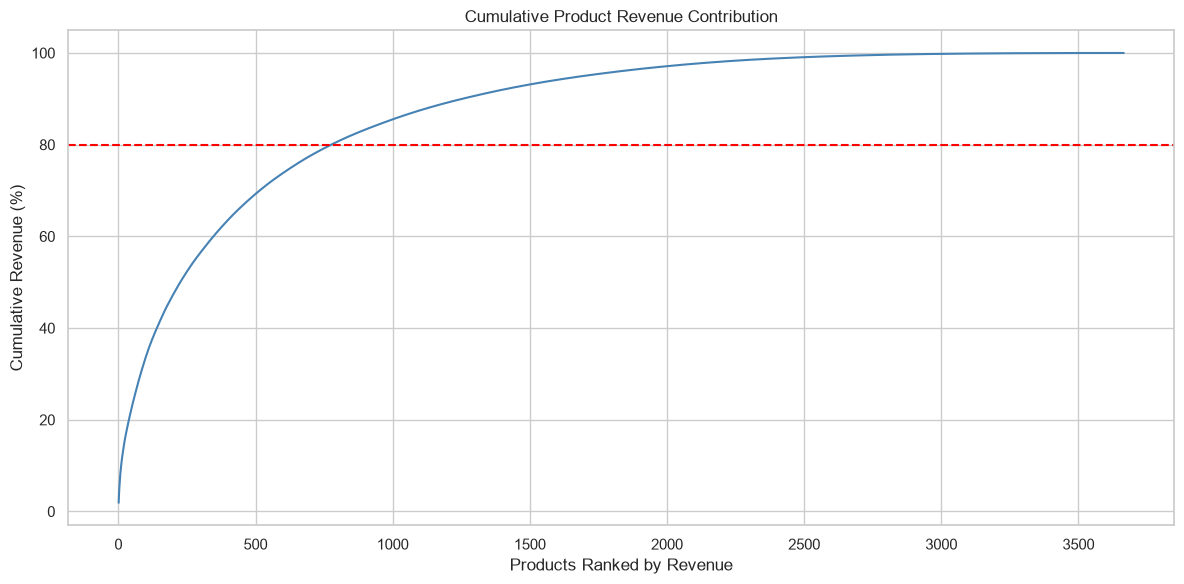

In [18]:
# Product revenue concentration
product_pareto = (
    sales_df.groupby('StockCode')
    .agg(
        Description=('Description', 'first'),
        Revenue=('TotalRevenue', 'sum')
    )
    .reset_index()
    .sort_values('Revenue', ascending=False)
)

product_pareto['Cumulative_Revenue'] = (
    product_pareto['Revenue'].cumsum()
)

product_pareto['Cumulative_Revenue_Percent'] = (
    product_pareto['Cumulative_Revenue']
    / product_pareto['Revenue'].sum()
    * 100
)

products_for_80_percent = (
    product_pareto['Cumulative_Revenue_Percent'] <= 80
).sum() + 1

print('--- Product Pareto Analysis ---')
print(
    f'{products_for_80_percent:,} products generate approximately '
    '80% of product revenue.'
)

display(product_pareto.head(20).style.format({
    'Revenue': '${:,.2f}',
    'Cumulative_Revenue': '${:,.2f}',
    'Cumulative_Revenue_Percent': '{:.1f}%'
}))

# Customer revenue concentration
customer_pareto = (
    sales_df.groupby('CustomerID')
    .agg(Revenue=('TotalRevenue', 'sum'))
    .reset_index()
    .sort_values('Revenue', ascending=False)
)

customer_pareto['Cumulative_Revenue'] = (
    customer_pareto['Revenue'].cumsum()
)

customer_pareto['Cumulative_Revenue_Percent'] = (
    customer_pareto['Cumulative_Revenue']
    / customer_pareto['Revenue'].sum()
    * 100
)

customers_for_80_percent = (
    customer_pareto['Cumulative_Revenue_Percent'] <= 80
).sum() + 1

print('\n--- Customer Pareto Analysis ---')
print(
    f'{customers_for_80_percent:,} customers generate approximately '
    '80% of customer revenue.'
)

display(customer_pareto.head(20).style.format({
    'Revenue': '${:,.2f}',
    'Cumulative_Revenue': '${:,.2f}',
    'Cumulative_Revenue_Percent': '{:.1f}%'
}))

# Visualise product revenue concentration
plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(product_pareto) + 1),
    product_pareto['Cumulative_Revenue_Percent'],
    color='steelblue'
)

plt.axhline(80, color='red', linestyle='--')
plt.title('Cumulative Product Revenue Contribution')
plt.xlabel('Products Ranked by Revenue')
plt.ylabel('Cumulative Revenue (%)')
plt.tight_layout()
plt.show()

# Pareto Analysis of Products and Customers

## Executive Summary

Pareto analysis measures revenue concentration by ranking products and customers from highest to lowest revenue and calculating cumulative contribution.

The analysis found that:

- **776 products** generated approximately 80% of product revenue.
- **1,130 customers** generated approximately 80% of customer revenue.

## Product Revenue Concentration

The top product was **PAPER CRAFT, LITTLE BIRDIE**, generating **$168,469.60**, or approximately **1.9%** of product revenue.

The first five products generated approximately **6.5%** of cumulative product revenue. The first ten generated approximately **10.0%**.

This indicates that product revenue is distributed across a broad assortment rather than being controlled by only a few products.

## Customer Revenue Concentration

The highest-value customer generated **$280,206.02**, representing approximately **3.2%** of customer revenue.

The top five customers generated approximately **11.8%** of revenue. Approximately 1,130 customers were required to reach 80% of customer revenue.

Customer revenue is therefore concentrated among important high-value customers, but not dependent on only a handful of customers.

## Business Interpretation

The customer base shows more concentration than the product assortment. This means customer retention and account management are important, while product planning requires attention across a broad range of products.

The analysis includes operational entries such as POSTAGE and Manual. These should be separated from ordinary merchandise in a refined product Pareto analysis.

## Recommendations

1. Protect high-value customers through retention and account-management strategies.
2. Maintain availability across the broad range of products contributing to revenue.
3. Create separate Pareto analyses for merchandise and operational codes.
4. Combine Pareto results with return rates and sales velocity.
5. Review the top 10, top 20, and top 100 customers regularly for concentration risk.

# CUSTOMER LIFETIME VALUE ANALYSIS

In [19]:
customer_value = (
    sales_df.groupby('CustomerID')
    .agg(
        Total_Revenue=('TotalRevenue', 'sum'),
        Total_Orders=('InvoiceNo', 'nunique'),
        First_Purchase=('InvoiceDate', 'min'),
        Last_Purchase=('InvoiceDate', 'max')
    )
    .reset_index()
)

customer_value['Average_Order_Value'] = (
    customer_value['Total_Revenue']
    / customer_value['Total_Orders']
)

customer_value['Customer_Lifespan_Days'] = (
    customer_value['Last_Purchase']
    - customer_value['First_Purchase']
).dt.days

customer_value['Customer_Lifespan_Months'] = (
    customer_value['Customer_Lifespan_Days'] / 30.44
)

# Historical customer value
customer_value['Historical_Lifetime_Value'] = (
    customer_value['Total_Revenue']
)

# Estimate annualised value only for customers active for at least 30 days
customer_value['Estimated_Annual_Value'] = np.where(
    customer_value['Customer_Lifespan_Days'] >= 30,
    customer_value['Total_Revenue']
    / customer_value['Customer_Lifespan_Days']
    * 365,
    np.nan
)

print('--- Customer Lifetime Value Summary ---')
print(
    f"Average historical customer value: "
    f"${customer_value['Historical_Lifetime_Value'].mean():,.2f}"
)
print(
    f"Median historical customer value: "
    f"${customer_value['Historical_Lifetime_Value'].median():,.2f}"
)
print(
    f"Average order value per customer: "
    f"${customer_value['Average_Order_Value'].mean():,.2f}"
)

top_lifetime_customers = (
    customer_value
    .sort_values(
        'Historical_Lifetime_Value',
        ascending=False
    )
    .head(20)
)

print('\n--- Top 20 Customers by Historical Lifetime Value ---')

display(
    top_lifetime_customers.style.format({
        'Total_Revenue': '${:,.2f}',
        'Total_Orders': '{:,.0f}',
        'Average_Order_Value': '${:,.2f}',
        'Customer_Lifespan_Days': '{:,.0f}',
        'Customer_Lifespan_Months': '{:,.1f}',
        'Historical_Lifetime_Value': '${:,.2f}',
        'Estimated_Annual_Value': '${:,.2f}'
    })
)

# Customer value segments
customer_value['Value_Segment'] = pd.qcut(
    customer_value['Historical_Lifetime_Value'].rank(
        method='first'
    ),
    4,
    labels=[
        'Low Value',
        'Medium-Low Value',
        'Medium-High Value',
        'High Value'
    ]
)

value_segment_summary = (
    customer_value.groupby('Value_Segment', observed=False)
    .agg(
        Customers=('CustomerID', 'nunique'),
        Average_Revenue=('Total_Revenue', 'mean'),
        Total_Revenue=('Total_Revenue', 'sum'),
        Average_Orders=('Total_Orders', 'mean')
    )
    .reset_index()
)

print('\n--- Customer Value Segment Summary ---')

display(
    value_segment_summary.style.format({
        'Customers': '{:,.0f}',
        'Average_Revenue': '${:,.2f}',
        'Total_Revenue': '${:,.2f}',
        'Average_Orders': '{:,.2f}'
    })
)

--- Customer Lifetime Value Summary ---
Average historical customer value: $2,048.69
Median historical customer value: $668.57
Average order value per customer: $417.65

--- Top 20 Customers by Historical Lifetime Value ---


,CustomerID,Total_Revenue,Total_Orders,First_Purchase,Last_Purchase,Average_Order_Value,Customer_Lifespan_Days,Customer_Lifespan_Months,Historical_Lifetime_Value,Estimated_Annual_Value
1689,14646,"$280,206.02",73,2010-12-20 10:09:00,2011-12-08 12:12:00,"$3,838.44",353,11.6,"$280,206.02","$289,731.44"
4201,18102,"$259,657.30",60,2010-12-07 16:42:00,2011-12-09 11:50:00,"$4,327.62",366,12.0,"$259,657.30","$258,947.85"
3728,17450,"$194,390.79",46,2010-12-07 09:23:00,2011-12-01 13:29:00,"$4,225.89",359,11.8,"$194,390.79","$197,639.66"
3008,16446,"$168,472.50",2,2011-05-18 09:52:00,2011-12-09 09:15:00,"$84,236.25",204,6.7,"$168,472.50","$301,433.64"
1879,14911,"$143,711.17",201,2010-12-01 14:05:00,2011-12-08 15:54:00,$714.98,372,12.2,"$143,711.17","$141,006.93"
55,12415,"$124,914.53",21,2011-01-06 11:12:00,2011-11-15 14:22:00,"$5,948.31",313,10.3,"$124,914.53","$145,667.10"
1333,14156,"$117,210.08",55,2010-12-03 11:48:00,2011-11-30 10:54:00,"$2,131.09",361,11.9,"$117,210.08","$118,508.81"
3771,17511,"$91,062.38",31,2010-12-01 10:19:00,2011-12-07 10:12:00,"$2,937.50",370,12.2,"$91,062.38","$89,831.81"
2702,16029,"$80,850.84",63,2010-12-01 09:57:00,2011-11-01 10:27:00,"$1,283.35",335,11.0,"$80,850.84","$88,091.21"
0,12346,"$77,183.60",1,2011-01-18 10:01:00,2011-01-18 10:01:00,"$77,183.60",0,0.0,"$77,183.60",$nan



--- Customer Value Segment Summary ---


,Value_Segment,Customers,Average_Revenue,Total_Revenue,Average_Orders
0,Low Value,"1,085",$178.03,"$193,166.38",1.26
1,Medium-Low Value,"1,084",$461.91,"$500,706.78",1.88
2,Medium-High Value,"1,084","$1,066.18","$1,155,744.35",3.52
3,High Value,"1,085","$6,486.26","$7,037,591.38",10.43


# Customer Lifetime Value Analysis

## Executive Summary

This analysis estimates historical customer value using completed sales. It measures total revenue, order count, average order value, and the time between a customer's first and last recorded purchase.

The average historical customer value was **$2,048.69**, while the median was **$668.57**. The difference shows that a relatively small group of high-value customers raises the average.

## Customer Value Summary

| Value Segment | Customers | Average Revenue | Total Revenue | Average Orders |
|---|---:|---:|---:|---:|
| Low Value | 1,085 | $178.03 | $193,166.38 | 1.26 |
| Medium-Low Value | 1,084 | $461.91 | $500,706.78 | 1.88 |
| Medium-High Value | 1,084 | $1,066.18 | $1,155,744.35 | 3.52 |
| High Value | 1,085 | $6,486.26 | $7,037,591.38 | 10.43 |

## Key Findings

- High-value customers generated **$7.04M**, the majority of total customer revenue.
- High-value customers placed an average of **10.43 orders**.
- Low-value customers averaged only **1.26 orders** and generated **$178.03** each.
- The highest-value customer generated **$280,206.02** from 73 orders.
- The median customer value of **$668.57** is more representative of the typical customer than the mean of $2,048.69.
- Some customers generated very high revenue from only one or two unusually large orders.

## Important Limitation

This is historical customer value, not a fully predictive customer lifetime value model. The dataset does not contain profit margins, acquisition costs, future purchase behaviour, or customer churn dates.

The estimated annual value is an extrapolation based on the observed customer lifespan and should be treated as a planning estimate, not a forecast.

## Recommendations

1. Protect high-value customers because they account for most revenue.
2. Use the median value to describe the typical customer.
3. Investigate one-order customers with unusually high revenue separately.
4. Use profit margins and acquisition costs in a future CLV model.
5. Combine lifetime value with RFM segments for retention prioritisation.

# COUNTRY-LEVEL CUSTOMER VALUE ANALYSIS

--- Countries Ranked by Revenue per Customer ---


,Country,Revenue,Customers,Orders,Units_Sold,Revenue_Per_Customer,Orders_Per_Customer,Units_Per_Order
10,EIRE,"$265,262.46",3,260,"140,133","$88,420.82",86.67,538.97
23,Netherlands,"$285,446.34",9,94,"200,361","$31,716.26",10.44,"2,131.50"
29,Singapore,"$21,279.29",1,7,"5,241","$21,279.29",7.00,748.71
0,Australia,"$138,453.81",9,57,"83,891","$15,383.76",6.33,"1,471.77"
31,Sweden,"$38,367.83",8,36,"36,078","$4,795.98",4.50,"1,002.17"
19,Japan,"$37,416.37",8,19,"26,016","$4,677.05",2.38,"1,369.26"
16,Iceland,"$4,310.00",1,7,"2,458","$4,310.00",7.00,351.14
24,Norway,"$36,165.44",10,36,"19,336","$3,616.54",3.60,537.11
32,Switzerland,"$56,443.95",21,51,"30,082","$2,687.81",2.43,589.84
14,Germany,"$228,678.40",94,457,"119,154","$2,432.75",4.86,260.73



--- Established Markets (at least 5 customers) ---


,Country,Revenue,Customers,Orders,Units_Sold,Revenue_Per_Customer,Orders_Per_Customer,Units_Per_Order
23,Netherlands,"$285,446.34",9,94,"200,361","$31,716.26",10.44,"2,131.50"
0,Australia,"$138,453.81",9,57,"83,891","$15,383.76",6.33,"1,471.77"
31,Sweden,"$38,367.83",8,36,"36,078","$4,795.98",4.50,"1,002.17"
19,Japan,"$37,416.37",8,19,"26,016","$4,677.05",2.38,"1,369.26"
24,Norway,"$36,165.44",10,36,"19,336","$3,616.54",3.60,537.11
32,Switzerland,"$56,443.95",21,51,"30,082","$2,687.81",2.43,589.84
14,Germany,"$228,678.40",94,457,"119,154","$2,432.75",4.86,260.73
13,France,"$208,934.31",87,389,"111,428","$2,401.54",4.47,286.45
6,Channel Islands,"$20,440.54",9,26,"9,485","$2,271.17",2.89,364.81
9,Denmark,"$18,955.34",9,18,"8,235","$2,106.15",2.00,457.50


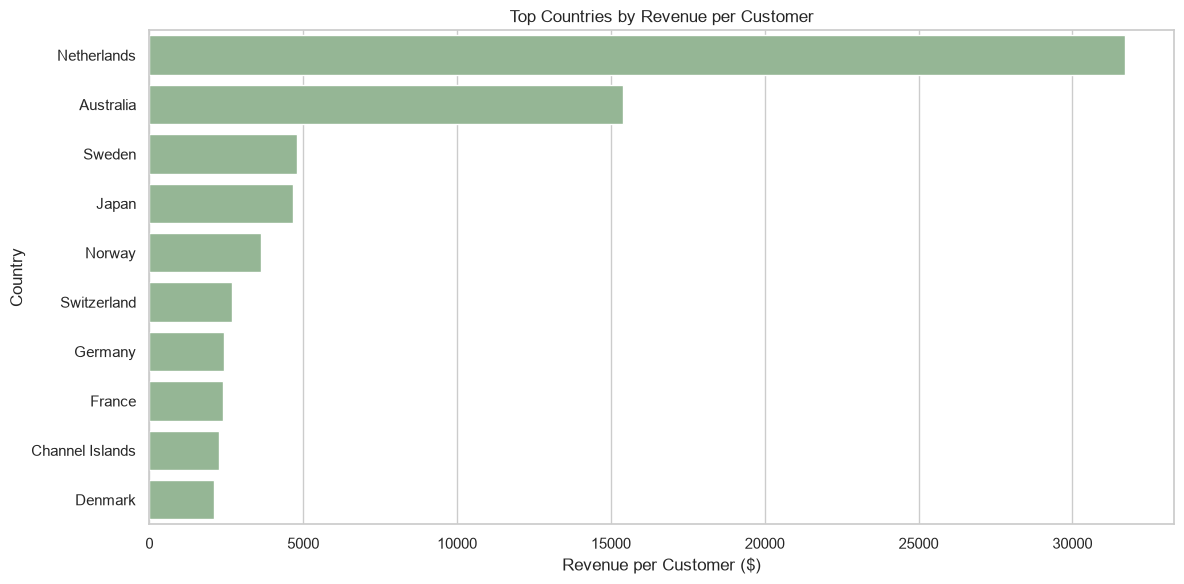

In [20]:
country_customer_value = (
    sales_df.groupby('Country')
    .agg(
        Revenue=('TotalRevenue', 'sum'),
        Customers=('CustomerID', 'nunique'),
        Orders=('InvoiceNo', 'nunique'),
        Units_Sold=('Quantity', 'sum')
    )
    .reset_index()
)

country_customer_value['Revenue_Per_Customer'] = (
    country_customer_value['Revenue']
    / country_customer_value['Customers']
)

country_customer_value['Orders_Per_Customer'] = (
    country_customer_value['Orders']
    / country_customer_value['Customers']
)

country_customer_value['Units_Per_Order'] = (
    country_customer_value['Units_Sold']
    / country_customer_value['Orders']
)

country_customer_value = (
    country_customer_value
    .sort_values('Revenue_Per_Customer', ascending=False)
)

print('--- Countries Ranked by Revenue per Customer ---')

display(
    country_customer_value.head(20).style.format({
        'Revenue': '${:,.2f}',
        'Customers': '{:,.0f}',
        'Orders': '{:,.0f}',
        'Units_Sold': '{:,.0f}',
        'Revenue_Per_Customer': '${:,.2f}',
        'Orders_Per_Customer': '{:,.2f}',
        'Units_Per_Order': '{:,.2f}'
    })
)

# Exclude countries with very small customer bases for a fairer comparison
minimum_country_customers = 5

established_markets = country_customer_value[
    country_customer_value['Customers']
    >= minimum_country_customers
].copy()

print(
    f'\n--- Established Markets '
    f'(at least {minimum_country_customers} customers) ---'
)

display(
    established_markets.head(20).style.format({
        'Revenue': '${:,.2f}',
        'Customers': '{:,.0f}',
        'Orders': '{:,.0f}',
        'Units_Sold': '{:,.0f}',
        'Revenue_Per_Customer': '${:,.2f}',
        'Orders_Per_Customer': '{:,.2f}',
        'Units_Per_Order': '{:,.2f}'
    })
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=established_markets.head(10),
    x='Revenue_Per_Customer',
    y='Country',
    color='darkseagreen'
)

plt.title('Top Countries by Revenue per Customer')
plt.xlabel('Revenue per Customer ($)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# Country-Level Customer Value Analysis

## Executive Summary

This analysis compares countries using revenue per customer, orders per customer, and units per order. Countries with very small customer bases can produce extreme averages, so established-market results require more cautious interpretation.

The established-market table includes countries with at least five customers.

## Key Findings

Among established markets:

- The Netherlands generated **$31,716.26 per customer** from 9 customers.
- Australia generated **$15,383.76 per customer** from 9 customers.
- Sweden generated **$4,795.98 per customer** from 8 customers.
- Japan generated **$4,677.05 per customer** from 8 customers.
- Norway generated **$3,616.54 per customer** from 10 customers.
- Germany generated **$2,432.75 per customer** from 94 customers.
- France generated **$2,401.54 per customer** from 87 customers.
- The United Kingdom generated **$1,858.42 per customer** from 3,920 customers.

## Market Comparison

The Netherlands recorded **10.44 orders per customer** and **2,131.50 units per order**, indicating highly concentrated, large-volume purchasing.

Australia also recorded high purchase volume, with **6.33 orders per customer** and **1,471.77 units per order**.

Germany and France had much broader customer bases but lower revenue per customer than the Netherlands and Australia. This makes them more suitable for scalable market development rather than only high-value account management.

## Important Limitation

Revenue per customer is highly sensitive to the number of customers. A country with one or two customers can rank highly because of a single large order.

The United Kingdom's lower revenue per customer is not evidence of weak performance; it reflects its much larger and broader customer base.

## Recommendations

1. Protect high-value international accounts in the Netherlands and Australia.
2. Treat Germany and France as broader, scalable markets.
3. Use minimum customer thresholds when comparing markets.
4. Analyse median customer value alongside average value.
5. Investigate large-volume international orders to distinguish wholesale from ordinary retail demand.

# SEASONAL PRODUCT ANALYSIS

--- Products Ranked by Peak Monthly Revenue ---


,StockCode,Description,Month,Month_Name,Revenue,Units_Sold,Orders
21642,23843,"PAPER CRAFT , LITTLE BIRDIE",12,Dec,"$168,469.60","80,995",1
19422,23166,MEDIUM CERAMIC TOP STORAGE JAR,1,Jan,"$77,183.60","74,215",1
13032,22502,PICNIC BASKET WICKER 60 PIECES,6,Jun,"$39,619.50",61,2
18784,23084,RABBIT NIGHT LIGHT,11,Nov,"$23,190.41","12,352",437
12218,22423,REGENCY CAKESTAND 3 TIER,12,Dec,"$22,113.78","1,945",184
29283,M,Manual,10,Oct,"$21,183.63","1,010",39
9059,22086,PAPER CHAIN KIT 50'S CHRISTMAS,11,Nov,"$16,109.51","5,909",343
27443,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,Jan,"$14,962.05","5,461",155
22768,47566,PARTY BUNTING,5,May,"$13,408.25","3,015",203
29293,POST,POSTAGE,5,May,"$13,358.75",243,88



--- Most Seasonally Concentrated Products ---


,StockCode,Description,Month,Month_Name,Revenue,Total_Revenue,Peak_Month_Revenue,Peak_Month_Share
0,23843,"PAPER CRAFT , LITTLE BIRDIE",12,Dec,"$168,469.60","$168,469.60","$168,469.60",100.0%
3647,22034,ROBIN CHRISTMAS CARD,12,Dec,$1.26,$1.26,$1.26,100.0%
3645,37351,ORANGE FLOWER MUG,3,Mar,$1.56,$1.56,$1.56,100.0%
3643,84551,CROCHET DOG KEYRING,6,Jun,$1.65,$1.65,$1.65,100.0%
3642,84550,CROCHET LILAC/RED BEAR KEYRING,11,Nov,$1.65,$1.65,$1.65,100.0%
3641,23664,FLOWER SHOP DESIGN MUG,11,Nov,$1.65,$1.65,$1.65,100.0%
3640,22146,EASTER CRAFT IVY WREATH WITH CHICK,1,Jan,$1.95,$1.95,$1.95,100.0%
3639,22323,PINK POLKADOT KIDS BAG,1,Jan,$1.95,$1.95,$1.95,100.0%
3637,81953B,ROUND BLUE CLOCK WITH SUCKER,7,Jul,$2.09,$2.09,$2.09,100.0%
3636,47579,TEA TIME BREAKFAST BASKET,12,Dec,$2.10,$2.10,$2.10,100.0%


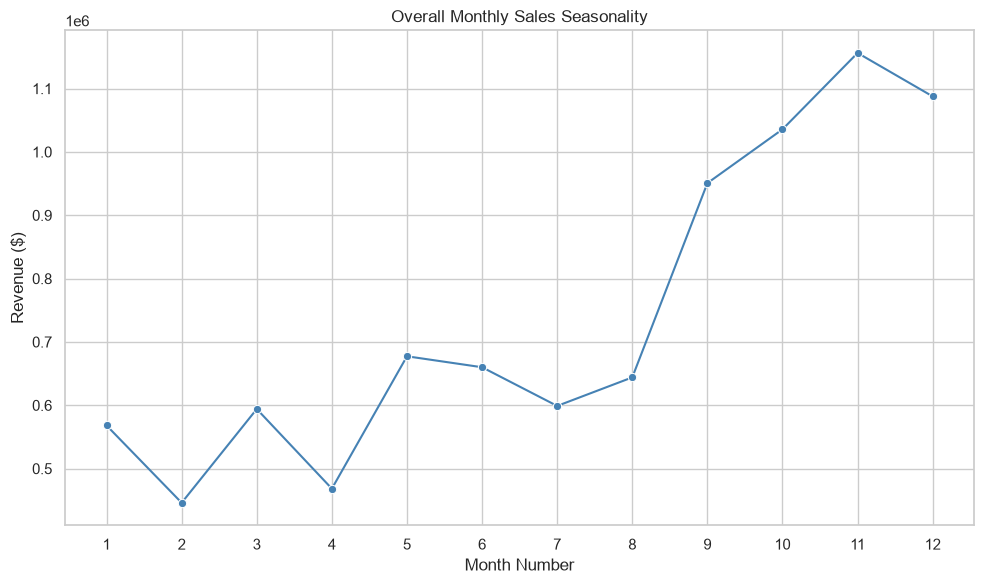

In [21]:
seasonal_sales = sales_df.copy()

seasonal_sales['Month'] = (
    seasonal_sales['InvoiceDate'].dt.month
)

seasonal_sales['Month_Name'] = (
    seasonal_sales['InvoiceDate'].dt.strftime('%b')
)

# Monthly product revenue
monthly_product_revenue = (
    seasonal_sales
    .groupby(['StockCode', 'Description', 'Month', 'Month_Name'])
    .agg(
        Revenue=('TotalRevenue', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

# Identify each product's strongest sales month
peak_product_months = (
    monthly_product_revenue
    .sort_values(
        ['StockCode', 'Revenue'],
        ascending=[True, False]
    )
    .groupby('StockCode')
    .head(1)
    .sort_values('Revenue', ascending=False)
)

print('--- Products Ranked by Peak Monthly Revenue ---')

display(
    peak_product_months.head(20).style.format({
        'Revenue': '${:,.2f}',
        'Units_Sold': '{:,.0f}',
        'Orders': '{:,.0f}'
    })
)

# Calculate how concentrated each product's sales are in its peak month
product_month_totals = (
    monthly_product_revenue
    .groupby('StockCode')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Peak_Month_Revenue=('Revenue', 'max')
    )
    .reset_index()
)

product_month_totals['Peak_Month_Share'] = (
    product_month_totals['Peak_Month_Revenue']
    / product_month_totals['Total_Revenue']
    * 100
)

seasonal_products = (
    peak_product_months[
        ['StockCode', 'Description', 'Month', 'Month_Name', 'Revenue']
    ]
    .merge(
        product_month_totals,
        on='StockCode',
        how='left'
    )
    .sort_values('Peak_Month_Share', ascending=False)
)

print('\n--- Most Seasonally Concentrated Products ---')

display(
    seasonal_products.head(20).style.format({
        'Revenue': '${:,.2f}',
        'Total_Revenue': '${:,.2f}',
        'Peak_Month_Revenue': '${:,.2f}',
        'Peak_Month_Share': '{:.1f}%'
    })
)

# Overall monthly sales pattern
monthly_seasonality = (
    seasonal_sales.groupby('Month')
    .agg(
        Revenue=('TotalRevenue', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_seasonality,
    x='Month',
    y='Revenue',
    marker='o',
    color='steelblue'
)

plt.title('Overall Monthly Sales Seasonality')
plt.xlabel('Month Number')
plt.ylabel('Revenue ($)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Seasonal Product Analysis

## Executive Summary

The analysis examined monthly product revenue to identify each product's strongest sales month and the share of total product revenue generated during that peak month.

Overall sales increased substantially from late summer into the final quarter. Monthly revenue peaked in **November**, at approximately **$1.16M**, followed by October at approximately **$1.04M** and September at approximately **$950.7K**.

December revenue should be treated cautiously because the dataset ends on 9 December.

## Overall Seasonal Pattern

| Month | Approximate Revenue |
|---:|---:|
| January | $568.1K |
| February | $446.1K |
| March | $594.1K |
| April | $468.4K |
| May | $677.4K |
| June | $660.0K |
| July | $599.0K |
| August | $644.1K |
| September | $950.7K |
| October | $1.04M |
| November | $1.16M |
| December* | $517.2K |

*December is incomplete.*

## Key Findings

- Revenue was strongest from September through November.
- Several seasonal and Christmas-related products reached their highest revenue in November or December.
- Examples include:
  - **RABBIT NIGHT LIGHT**, with peak monthly revenue of **$23,190.41** in November.
  - **PAPER CHAIN KIT 50'S CHRISTMAS**, with peak monthly revenue of **$16,109.51** in November.
  - **PARTY BUNTING**, with peak monthly revenue of **$13,408.25** in May.
  - **JUMBO BAG RED RETROSPOT**, with peak monthly revenue of **$10,711.91** in November.
- PAPER CRAFT, LITTLE BIRDIE generated all of its recorded revenue, **$168,469.60**, in December. This was associated with one unusually large transaction and should not be treated as normal seasonal demand.
- Many products show 100% peak-month concentration because they were sold only once or had very low total revenue.

## Important Interpretation

A 100% peak-month share does not automatically prove that a product is seasonal. It may simply mean that the product appeared in one month or had very few transactions.

The strongest seasonal evidence comes from products with meaningful revenue, multiple orders, and repeated activity across several months.

## Recommendations

1. Prepare seasonal inventory and fulfilment capacity before September.
2. Monitor Christmas-related products before November and December.
3. Exclude one-time or very low-revenue products from seasonal decision-making.
4. Add minimum order and revenue thresholds before labelling products as seasonal.
5. Combine seasonality with product velocity, return rates, and repeat-order patterns.
6. Avoid using incomplete December results as a full-month seasonal comparison.

# EXPORTING FINALISED ANALYSIS FILES

In [23]:
# EXPORTING FINALISED ANALYSIS FILES

cleaned_export = cleaned_df.copy()

cleaned_export['TotalRevenue'] = (
    cleaned_export['Quantity']
    * cleaned_export['UnitPrice']
)

cleaned_export.to_csv(
    'data/cleaned_ecommerce.csv',
    index=False
)

sales_df.to_csv(
    'data/completed_sales_ecommerce.csv',
    index=False
)

rfm.to_csv(
    'data/customer_rfm_segments.csv',
    index=False
)

cancellations.to_csv(
    'data/cancellations_and_returns.csv',
    index=False
)

product_insights.to_csv(
    'data/product_performance.csv',
    index=False
)

customer_orders.to_csv(
    'data/repeat_purchase_analysis.csv',
    index=False
)

retention_table.to_csv(
    'data/cohort_retention_analysis.csv'
)

cohort_revenue.to_csv(
    'data/cohort_revenue_analysis.csv'
)

product_return_analysis.to_csv(
    'data/product_return_rate_analysis.csv',
    index=False
)

print('All final analysis files were successfully saved.')

All final analysis files were successfully saved.
